In [52]:
import numpy as np
import pandas as pd

from cosinor_utils import apply_sliding_cosinor
from ar_model_utils import apply_sliding_window
from plot_utils import *
from data_utils import *
from stats_utils import *
from spectra_utils import *
from model_evaluation import leave_one_patient_out_logistic_regression, plot_model_metrics
from circadian_utils import *

from datetime import timedelta, datetime, date
from datetime import time as dttime
import datetime as dt
from zoneinfo import ZoneInfo

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.transforms import Bbox
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

import re
import json
from pathlib import Path
import yaml
from tqdm.notebook import tqdm
from scipy import stats
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from collections.abc import Iterable
from statsmodels.tsa.stattools import acf
import itertools
from scipy.signal import welch

import re
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 144)
pd.set_option('display.max_colwidth', None)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
def mm_to_pt(mm):
    """Convert a length in millimeters to points (1 pt = 1/72 in = 25.4/72 mm)."""
    return mm * 72 / 25.4

# Set plotting parameters for manuscript figures
# These will look ugly in the notebook, but setting these parameters 
# makes it easier to edit them in Illustrator.
# Comment out these lines (or just don't run this cell) if you
# just want to see the plots in the notebook.

# Line widths: axes (spines) and tick marks
mpl.rcParams['axes.linewidth'] = 0.5
mpl.rcParams['xtick.major.width'] = 0.5
mpl.rcParams['xtick.minor.width'] = 0.5
mpl.rcParams['ytick.major.width'] = 0.5
mpl.rcParams['ytick.minor.width'] = 0.5

# Tick mark length: 0.75mm, for major and minor ticks on both axes
mpl.rcParams['xtick.major.size'] = mm_to_pt(0.75)
mpl.rcParams['xtick.minor.size'] = mm_to_pt(0.75)
mpl.rcParams['ytick.major.size'] = mm_to_pt(0.75)
mpl.rcParams['ytick.minor.size'] = mm_to_pt(0.75)

# Gap between the tip of the y tick marks and the y tick labels: 0.5mm
mpl.rcParams['ytick.major.pad'] = mm_to_pt(0.5)
mpl.rcParams['ytick.minor.pad'] = mm_to_pt(0.5)
mpl.rcParams['xtick.major.pad'] = mm_to_pt(0.5)
mpl.rcParams['xtick.minor.pad'] = mm_to_pt(0.5)

# Gap between the tick labels and the axis label: 0.1mm
mpl.rcParams['axes.labelpad'] = mm_to_pt(0.1)

# Font params
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']
mpl.rcParams['xtick.labelsize'] = 5
mpl.rcParams['ytick.labelsize'] = 5
mpl.rcParams['axes.labelsize'] = 6
mpl.rcParams['axes.titlesize'] = 7

# No background fill on the figure or individual axes (transparent on save, e.g. to SVG)
mpl.rcParams['figure.facecolor'] = 'none'
mpl.rcParams['axes.facecolor'] = 'none'
mpl.rcParams['savefig.facecolor'] = 'none'
mpl.rcParams['savefig.transparent'] = True

In [4]:
%%html
<style>
.cell-output-ipywidget-background {
    background-color: transparent !important;
}
:root {
    --jp-widgets-color: var(--vscode-editor-foreground);
    --jp-widgets-font-size: var(--vscode-editor-font-size);
}  
</style>
# Set tqdm styling to match window theme

In [5]:
COL_PAL = {
    "Pre-DBS": "#ffe900",
    "Non-Responder": "#ffb900",
    "Disinhibited": "#ff0000",
    "Responder": "#0000ff",
    "Transition": "#808080",
    "Unknown": "#808080",
    "Partial Responder": "#21cfff",
    "Relapse": "#f58012"
}

In [6]:
df = pd.read_parquet('data/df_for_paper.parq')
# df['state_label_str'] = df['state_label_str'].replace({'Relapse': 'Non-Responder'}) # read methods for more details

scale_df = pd.read_parquet('data/scale_df_for_paper.parq')
scale_df.dropna(subset=['YBOCS'], inplace=True)

In [7]:
# Relapse situations are handled per our definition of relapse described in the methods section of the paper. The following code implements those changes to the state labels.
df.loc[(df['pt_id'] == "B014") & (df['state_label_str'] == "Relapse"), 'state_label_str'] = 'Non-Responder'

b001_relapse_end_day = df.query('pt_id == "B001" and state_label_str == "Relapse"')['days_since_dbs'].max()
df.loc[(df['pt_id'] == "B001") & (df['days_since_dbs'] <= b001_relapse_end_day) & (df['days_since_dbs'] > 0), 'state_label_str'] = 'Transition'

In [8]:
# Add a new datetime type column with a fake DBS start date (in this case, Jan 1, 2030).
# By using a fake date, we remain HIPAA-compliant while still being able to plot the data in a time series format.
# If using real data, replace with actual timestamps of data.
# Note that time_bin_time is in the patient's home time zone, so the dummy_timestamp will also be in the same time zone.
base = pd.Timestamp(2030, 1, 1)
df['dummy_timestamp'] = (
    base
    + pd.to_timedelta(df['days_since_dbs'], unit='D')
    + pd.to_timedelta(df['time_bin_time'].apply(lambda t: t.hour),   unit='h')
    + pd.to_timedelta(df['time_bin_time'].apply(lambda t: t.minute), unit='m')
    + pd.to_timedelta(df['time_bin_time'].apply(lambda t: t.second), unit='s')
)

## Some stats just for fun

In [9]:
sample_cnts_dict = {
    'pt ID': [],
    'hemisphere': [],
    'total samples': [],
    'unique days': [],
    'days pre-DBS': [],
    'days post-DBS': [],
    'days non-responder': [],
    'days transition': [],
    'days responder': [],
    'days unknown': [],
}

for pt_id, pt_df in df.groupby('pt_id', sort=False):
    for hem in ['left', 'right']:
        hem_df = pt_df.dropna(subset=[f'lfp_{hem}_OvER_interpolate_z_scored'])
        sample_cnts_dict['pt ID'].append(pt_id)
        sample_cnts_dict['hemisphere'].append(hem)
        sample_cnts_dict['total samples'].append(hem_df[f'lfp_{hem}_OvER_interpolate_z_scored'].notna().sum())
        sample_cnts_dict['unique days'].append(hem_df['days_since_dbs'].nunique())
        sample_cnts_dict['days pre-DBS'].append(hem_df.loc[hem_df['days_since_dbs'] < 0, 'days_since_dbs'].nunique())
        sample_cnts_dict['days post-DBS'].append(hem_df.loc[hem_df['days_since_dbs'] >= 0, 'days_since_dbs'].nunique())
        sample_cnts_dict['days non-responder'].append(hem_df.loc[hem_df['state_label_str'] == 'Non-Responder', 'days_since_dbs'].nunique())
        sample_cnts_dict['days transition'].append(hem_df.loc[hem_df['state_label_str'] == 'Transition', 'days_since_dbs'].nunique())
        sample_cnts_dict['days responder'].append(hem_df.loc[hem_df['state_label_str'] == 'Responder', 'days_since_dbs'].nunique())
        sample_cnts_dict['days unknown'].append(hem_df.loc[hem_df['state_label_str'] == 'Unknown', 'days_since_dbs'].nunique())

sample_cnts_df = pd.DataFrame(sample_cnts_dict)

sample_cnts_df.loc['Total left'] = sample_cnts_df.query('hemisphere == "left"').sum(numeric_only=True)
sample_cnts_df.loc['Total left', 'hemisphere'] = 'left'
sample_cnts_df.loc['Total right'] = sample_cnts_df.query('hemisphere == "right"').sum(numeric_only=True)
sample_cnts_df.loc['Total right', 'hemisphere'] = 'right'

int_cols = [
    'total samples', 'unique days', 'days pre-DBS', 'days post-DBS',
    'days non-responder', 'days transition', 'days responder', 'days unknown'
]
sample_cnts_df[int_cols] = sample_cnts_df[int_cols].astype('Int64')

sample_cnts_df

,pt ID,hemisphere,total samples,unique days,days pre-DBS,days post-DBS,days non-responder,days transition,days responder,days unknown
0,AA001,left,19645,141,8,133,0,0,0,133
1,AA001,right,3321,27,8,19,0,0,0,19
2,AA002,left,18802,136,17,119,0,0,0,119
3,AA002,right,8820,65,17,48,0,0,0,48
4,AA004,left,13468,95,10,85,0,0,0,85
5,AA004,right,11243,94,10,84,0,0,0,84
6,B001,left,93065,650,49,601,0,433,167,1
7,B001,right,93065,650,49,601,0,433,167,1
8,B002,left,4808,38,7,31,15,0,0,2
9,B002,right,6480,50,7,43,27,0,0,2


In [10]:
left_unique_samples = df.dropna(subset=['lfp_left_OvER_interpolate_z_scored']).shape[0]
right_unique_samples = df.dropna(subset=['lfp_right_OvER_interpolate_z_scored']).shape[0]
print(f'Dataframe contains {left_unique_samples:,} left hemisphere and {right_unique_samples:,} right hemisphere samples from {df["pt_id"].nunique()} patients.')
print(f'This covers {sample_cnts_df.loc["Total left", "unique days"]:,} unique patient-days, with {sample_cnts_df.loc["Total left", "days pre-DBS"]:,} days pre-DBS and {sample_cnts_df.loc["Total left", "days post-DBS"]:,} days post-DBS.')
print(f'Patient hours: {left_unique_samples / 6:,.0f} left hemisphere and {right_unique_samples / 6:,.0f} right hemisphere hours of data at 10 minute intervals.')
print(f'The size of this dataset is equivalent to {left_unique_samples / (6 * 24 * 365):.2f} patient-years of left-hemisphere data at 10 minute intervals. ({right_unique_samples / (6 * 24 * 365):.2f} for the right hemisphere)')

left_day_counts, right_day_counts = [], []
for pt_id, pt_df in df.groupby('pt_id', sort=False):
    left_n_days = pt_df.dropna(subset=['lfp_left_OvER_interpolate_z_scored']).shape[0] / (6 * 24)
    right_n_days = pt_df.dropna(subset=['lfp_right_OvER_interpolate_z_scored']).shape[0] / (6 * 24)
    left_day_counts.append(left_n_days)
    right_day_counts.append(right_n_days)
avg_left_days = np.mean(left_day_counts)
avg_right_days = np.mean(right_day_counts)
std_left = np.std(left_day_counts)
std_right = np.std(right_day_counts)
print(f'This is an average of {avg_left_days:.2f} left hemisphere days (σ = {std_left:.2f}) and {avg_right_days:.2f} right hemisphere days (σ = {std_right:.2f}) per patient.')

Dataframe contains 709,086 left hemisphere and 608,532 right hemisphere samples from 24 patients.
This covers 5,065 unique patient-days, with 360 days pre-DBS and 4,705 days post-DBS.
Patient hours: 118,181 left hemisphere and 101,422 right hemisphere hours of data at 10 minute intervals.
The size of this dataset is equivalent to 13.49 patient-years of left-hemisphere data at 10 minute intervals. (11.58 for the right hemisphere)
This is an average of 205.18 left hemisphere days (σ = 215.52) and 176.08 right hemisphere days (σ = 223.54) per patient.


## Apply Models

In [11]:
tqdm.pandas(desc='Applying sliding cosinor model')
cosinor_result = df.groupby('pt_id').progress_apply(apply_sliding_cosinor, include_groups=False)
cosinor_result = cosinor_result.reset_index(level='pt_id').reset_index(drop=True)
df = df.merge(cosinor_result, on=['pt_id', 'days_since_dbs'], how='left')

Applying sliding cosinor model:   0%|          | 0/24 [00:00<?, ?it/s]

In [12]:
window_size = 3

df.reset_index(drop=True, inplace=True)
hem = 'left'

pt_groups = df.groupby('pt_id', group_keys=False)
ar_features = [f'lfp_{hem}_OvER_interpolate_z_scored_lag_1']
tqdm.pandas(desc=f'Applying autoregressive model for {hem} hem')
hem_results_df = pt_groups.progress_apply(
    lambda g: apply_sliding_window(
        g, ar_features, f'lfp_{hem}_OvER_interpolate_z_scored', window_size=window_size),
    include_groups=False
)
df = df.merge(
    hem_results_df,
    how='left',
    left_index=True,
    right_index=True
)

Applying autoregressive model for left hem:   0%|          | 0/24 [00:00<?, ?it/s]

## Figure 1

### 1a

The panel illustrating lead locations was made with LeadDBS 3.0. See methods section of paper for additional details.

### 1b

In [13]:
# Add a new datetime type column with a fake DBS start date (in this case, Jan 1, 2030).
# By using a fake date, we remain HIPAA-compliant while still being able to plot the data in a time series format.
# If using real data, replace with actual timestamps of data.
# Note that time_bin_time is in the patient's home time zone,
# so the dummy_timestamp will also be in the same time zone.
base = pd.Timestamp(2030, 1, 1)
df['dummy_timestamp'] = (
    base
    + pd.to_timedelta(df['days_since_dbs'], unit='D')
    + pd.to_timedelta(df['time_bin_time'].apply(lambda t: t.hour),   unit='h')
    + pd.to_timedelta(df['time_bin_time'].apply(lambda t: t.minute), unit='m')
    + pd.to_timedelta(df['time_bin_time'].apply(lambda t: t.second), unit='s')
)

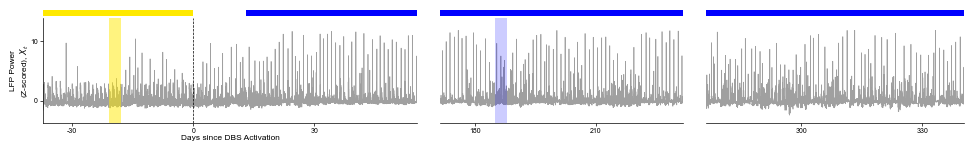

In [14]:
# Example left-hemisphere LFP time series plot for B011.
pt_df = df.query('pt_id == "B011"')

# This patient has extended gaps between when data were collected, so we split the data
# into three segments for more efficient plotting.
segment_bounds = [
    (None, 100),
    (100, 250),
    (250, None),
]
segments = []
for lo, hi in segment_bounds:
    if lo is None:
        seg = pt_df.query('days_since_dbs < @hi')
    elif hi is None:
        seg = pt_df.query('days_since_dbs > @lo')
    else:
        seg = pt_df.query('days_since_dbs > @lo and days_since_dbs < @hi')
    segments.append(seg)
    
pt_df_a, pt_df_b, pt_df_c = segments

seg_lengths = [
    (seg['dummy_timestamp'].max() - seg['dummy_timestamp'].min()).total_seconds()
    for seg in segments
]

dpi = 100
fig_width_pixels = 900 / 689.4269 * 705.1317 + 1  # very specific width to fit correctly in final figure layout
fig_height_pixels = 105

fig, axes = plt.subplots(
    figsize=(fig_width_pixels / dpi, fig_height_pixels / dpi),
    ncols=3,
    sharey='all',
    width_ratios=seg_lengths,
    dpi=dpi,
)
fig.subplots_adjust(wspace=0.08, left=0, right=1, top=1, bottom=0)

dbs_start_dt = datetime(2030, 1, 1)  # Dummy DBS start date

# Highlight windows unique to the first two segments (start date, span, color, alpha)
highlight_windows = {
    0: (dbs_start_dt - timedelta(days=21), dbs_start_dt - timedelta(days=18), "#FFE900", 0.5),
    1: (dbs_start_dt + timedelta(days=185), dbs_start_dt + timedelta(days=188), "#0000FF", 0.2),
}

for i, (ax, seg) in enumerate(zip(axes, segments)):
    ax.plot(
        seg['dummy_timestamp'],
        seg['lfp_left_OvER_interpolate_z_scored'],
        c='#A0A0A0',
        lw=0.5,
    )
    ax.set(xlim=(seg['dummy_timestamp'].min(), seg['dummy_timestamp'].max()))

    if i in highlight_windows:
        start, end, color, alpha = highlight_windows[i]
        ax.fill_between(
            [start, end],
            0, 1,
            color=color,
            alpha=alpha,
            transform=ax.get_xaxis_transform(),
            zorder=2,
            ec=None,
        )

    transform_timestamp_to_days(seg, ax, tick_spacing_days=30)

    # Only the first (leftmost) axis keeps labels, ticks, and the DBS activation line
    if i == 0:
        ax.set(
            yticks=[0, 10],
            xlabel='Days since DBS Activation',
            ylabel='LFP Power\n' + '(Z-scored), ' + r'$X_t$',
        )
        ax.axvline(dbs_start_dt, color='k', linestyle='--', lw=0.5)
    else:
        ax.tick_params(labelleft=False)
        ax.yaxis.set_ticks_position('none')
        ax.spines['left'].set_visible(False)

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # State-label rectangles above each segment's axis
    for state, state_df in seg.groupby('state_label_str', observed=True):
        if state in ['Unknown', 'Transition', 'Disinhibited']:
            continue
        rect = mpatches.Rectangle(
            (state_df['dummy_timestamp'].min(), 1.02),
            state_df['dummy_timestamp'].max() - state_df['dummy_timestamp'].min(),
            0.06,
            color=COL_PAL[state],
            label=state,
            ec=None,
            zorder=3,
            transform=mpl.transforms.blended_transform_factory(ax.transData, ax.transAxes),
            clip_on=False,
        )
        ax.add_patch(rect)

fig.set_size_inches(fig_width_pixels / dpi, fig_height_pixels / dpi)
plt.savefig('figures/1b.svg', dpi=dpi, bbox_inches='tight', pad_inches=0)
plt.show()

### 1c

The panel showing the schematic of the linear autoregressive model was made from scratch in Adobe Illustrator.

### 1d

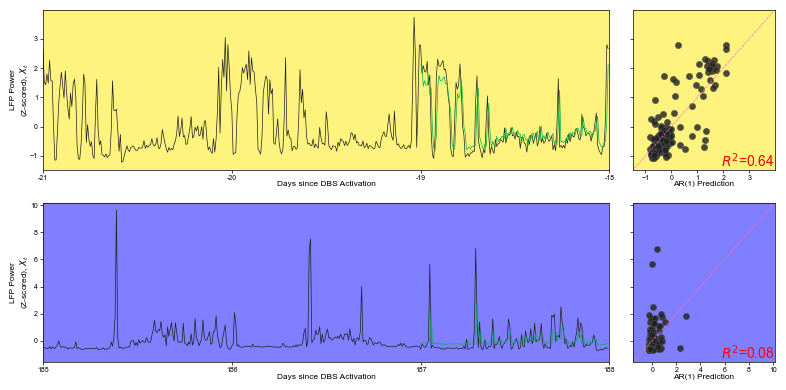

In [15]:
# Show blow-ups of 3-day windows within the B011 time series and correlations.
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(8, 4), width_ratios=[4,1], sharey='row')
day_ranges = [(-21, -18), (185, 188)]
facecolors = [COL_PAL['Pre-DBS'], COL_PAL['Responder']]
df.sort_values(by='dummy_timestamp', inplace=True)
for (start_day, end_day), ax_row, facecolor in zip(day_ranges, axs, facecolors):
    pt_df = df.query('pt_id == "B011" and (@start_day-1) <= days_since_dbs < @end_day').copy()
    last_day_df = df.query('pt_id == "B011" and days_since_dbs == (@end_day-1)').copy()
    ax_row[0].plot(
        pt_df['dummy_timestamp'],
        pt_df['lfp_left_OvER_interpolate_z_scored'], 
        c='#202020',
        lw=0.5
    )
    ax_row[0].plot(
        last_day_df['dummy_timestamp'],
        last_day_df['lfp_left_OvER_interpolate_preds'],
        c='#00b447',
        lw=0.5
    )
    ax_row[1].scatter(
        x=last_day_df['lfp_left_OvER_interpolate_preds'],
        y=last_day_df['lfp_left_OvER_interpolate_z_scored'],
        c='#202020',
        edgecolor='#4c4c4c',
        s=20,
        lw=0.5,
        alpha=0.8
    )
    
    ylims = ax_row[1].get_ylim()
    ax_row[1].plot(
        [-10, 10], [-10, 10],
        c='#ff69b4',
        ls='--',
        lw=0.5
    )
    ax_row[1].set(
        xlabel='AR(1) Prediction',
        ylim=ylims,
        xlim=ylims,
        facecolor=add_alpha_to_color(facecolor, alpha=0.5),
    )
    transform_timestamp_to_days(pt_df, ax_row[0], tick_spacing_days=1)
    dbs_start_dt = datetime(2030, 1, 1, 0, 0, 0)
    ax_row[0].set(
        facecolor=add_alpha_to_color(facecolor, alpha=0.5),
        xlabel='Days since DBS Activation',
        ylabel='LFP Power\n' + '(Z-scored), ' + r'$X_t$',
        xlim=[dbs_start_dt + timedelta(days=start_day), dbs_start_dt + timedelta(days=end_day)]
    )
    r2_val = last_day_df['lfp_left_OvER_interpolate_R2'].iloc[0]
    ax_row[1].text(1, 0, f'$R^2$={r2_val:.2f}', ha='right', va='bottom', transform=ax_row[1].transAxes, color='r')

fig.tight_layout()
plt.savefig('figures/1d.svg', bbox_inches='tight', pad_inches=0)
plt.show()

### 1e

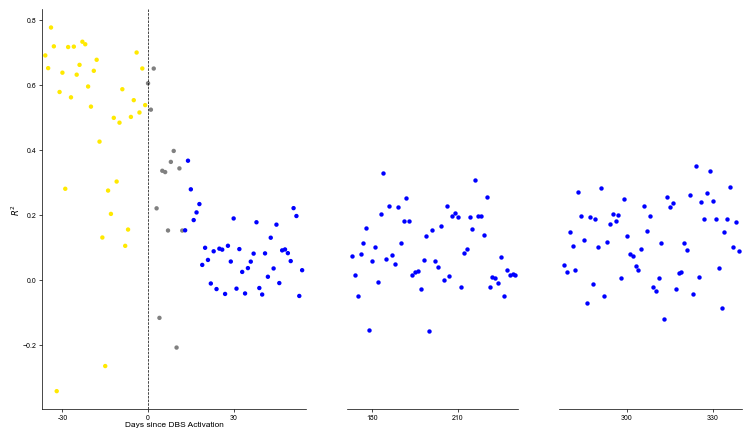

In [16]:
dpi = 100

day_df_a = pt_df_a.groupby(['pt_id', 'days_since_dbs']).head(1)
day_df_b = pt_df_b.groupby(['pt_id', 'days_since_dbs']).head(1)
day_df_c = pt_df_c.groupby(['pt_id', 'days_since_dbs']).head(1)
len_a = day_df_a['days_since_dbs'].max() - day_df_a['days_since_dbs'].min()
len_b = day_df_b['days_since_dbs'].max() - day_df_b['days_since_dbs'].min()
len_c = day_df_c['days_since_dbs'].max() - day_df_c['days_since_dbs'].min()

fig, (ax1, ax2, ax3) = plt.subplots(
    figsize=(7, 4),
    ncols=3,
    sharey='all',
    width_ratios=[len_a, len_b, len_c],
    dpi=dpi,
)
fig.subplots_adjust(wspace=0.2, left=0, right=1, top=1, bottom=0)

states = day_df_a['state_label_str'].values.astype(str)
states = np.where(states=='Disinhibited', 'Transition', states)
ax1.scatter(
    day_df_a['dummy_timestamp'],
    day_df_a['lfp_left_OvER_interpolate_R2'],
    s=10,
    c=[COL_PAL[sl] for sl in states],
    ec=None,
    lw=0,
)
ax1.set(
    xlim=(pt_df_a['dummy_timestamp'].min(), pt_df_a['dummy_timestamp'].max()),
    xlabel='Days since DBS Activation',
    ylabel=r'$R^2$',
    yticks=[-0.2, 0.0, 0.2, 0.4, 0.6, 0.8]
)
ax1.axvline(dbs_start_dt, color='k', linestyle='--', lw=0.5)
transform_timestamp_to_days(pt_df_a, ax1, tick_spacing_days=30)
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)

ax2.scatter(
    day_df_b['dummy_timestamp'],
    day_df_b['lfp_left_OvER_interpolate_R2'],
    s=10,
    c=COL_PAL['Responder'],
    ec=None,
    lw=0,
)
ax2.set(
    xlim=(day_df_b['dummy_timestamp'].min(), day_df_b['dummy_timestamp'].max()),
)
ax2.tick_params(labelleft=False)
ax2.yaxis.set_ticks_position('none')
transform_timestamp_to_days(day_df_b, ax2, tick_spacing_days=30)
ax2.spines['left'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)

ax3.scatter(
    day_df_c['dummy_timestamp'],
    day_df_c['lfp_left_OvER_interpolate_R2'],
    s=10,
    c=COL_PAL['Responder'],
    ec=None,
    lw=0,
)
ax3.set(
    xlim=(day_df_c['dummy_timestamp'].min(), day_df_c['dummy_timestamp'].max()),
)
ax3.tick_params(labelleft=False)
ax3.yaxis.set_ticks_position('none')
transform_timestamp_to_days(day_df_c, ax3, tick_spacing_days=30)
ax3.spines['left'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['top'].set_visible(False)

plt.savefig('figures/1e.svg', bbox_inches='tight', pad_inches=0)
plt.show()

## Figure 2

### 2a

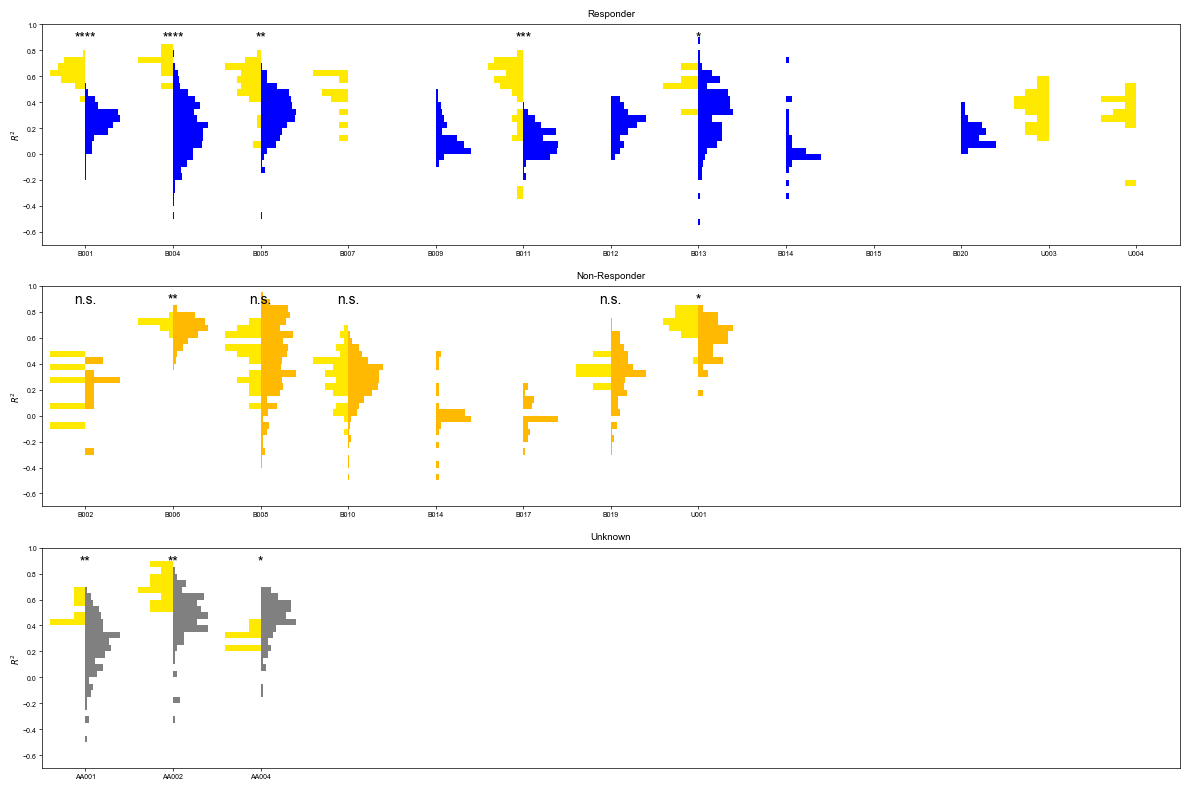

,pt_id,response_status,n1_raw,n2_raw,dof_raw,t_stat_raw,p_val_raw,ci_raw,hedges_g_raw,hedges_g_ci_raw,n1_neff,n2_neff,dof_neff,t_stat_neff,p_val_neff,ci_neff,hedges_g_neff,hedges_g_ci_neff
21,AA001,Unknown,7.0,128.0,9.490733,6.392403,9.992490e-05,"(0.17284233943074553, 0.35989196702910664)",1.260011,"(0.4887410587299532, 2.0312816570770185)",5.644774,13.943656,17.053155,3.768783,1.523985e-03,"(0.11728662746161445, 0.41544767899823776)",1.338205,"(0.31316484981856174, 2.3632446380968624)"
22,AA002,Unknown,15.0,114.0,24.620707,6.260447,1.607851e-06,"(0.15420209846751526, 0.30557662570978944)",1.204164,"(0.6492180920397341, 1.7591093247025962)",4.906006,29.673875,7.704768,3.470307,8.946888e-03,"(0.076103946974795, 0.3836747772025097)",1.186968,"(0.21286317006825162, 2.1610720128981042)"
23,AA004,Unknown,8.0,85.0,16.561204,-4.125275,7.428514e-04,"(-0.18429649839092305, -0.05940608801049669)",-0.766414,"(-1.4936415212755185, -0.03918718083850126)",3.487272,24.198377,7.932052,-2.496512,3.738400e-02,"(-0.23457219317176037, -0.009130393229659348)",-0.756735,"(-1.8643516716342639, 0.3508813909373575)"
0,B001,Responder,47.0,164.0,106.350511,25.533000,3.599912e-47,"(0.3444128856748351, 0.40239948370005996)",3.456407,"(2.994721620924501, 3.9180926185916056)",12.521504,55.207824,23.795279,13.723439,8.488506e-13,"(0.31722321685084715, 0.4295891525240479)",3.385085,"(2.5527648548955835, 4.217405657160704)"
13,B002,Non-Responder,5.0,12.0,6.425885,0.045601,9.650125e-01,"(-0.265601459432163, 0.27585466001340414)",0.025011,"(-0.9652476916360923, 1.015269372823066)",3.173602,6.828463,3.644412,0.035872,9.732615e-01,"(-0.4074052671837154, 0.4176584677649565)",0.023777,"(-1.1789862090859764, 1.2265409025782887)"
1,B004,Responder,8.0,322.0,9.023150,14.970022,1.116522e-07,"(0.4259227427025826, 0.5774919433730512)",2.430141,"(1.7060995090757767, 3.154181697931229)",4.391549,54.489569,6.945629,9.850153,2.487941e-05,"(0.3810762685350041, 0.6223384175406298)",2.442637,"(1.386703084553942, 3.4985706592366936)"
2,B005,Responder,43.0,385.0,55.897011,9.969841,5.204908e-14,"(0.20256015112866432, 0.3044348256028766)",1.403493,"(1.075157586531507, 1.7318288426981343)",8.164305,75.453630,9.459405,4.353371,1.636810e-03,"(0.1227404879546545, 0.3842544887768864)",1.390846,"(0.6449925166342587, 2.1366990545579845)"
14,B006,Non-Responder,13.0,787.0,15.925697,5.193194,9.015394e-05,"(0.03319886382250505, 0.07902831451676415)",0.512273,"(-0.03585449395198137, 1.0604000351689982)",7.158043,56.579514,25.105735,2.810702,9.447063e-03,"(0.015005198711693965, 0.09722197962757524)",0.527074,"(-0.2464065658033896, 1.3005536517319682)"
3,B007,Responder,NaN,NaN,NaN,NaN,NaN,"(nan, nan)",NaN,"(nan, nan)",NaN,NaN,NaN,NaN,NaN,"(nan, nan)",NaN,"(nan, nan)"
15,B008,Non-Responder,18.0,351.0,21.079652,0.341695,7.359633e-01,"(-0.08101729139377051, 0.11288394461522505)",0.057659,"(-0.41505571940377, 0.5303739754339656)",3.882366,27.917833,4.887843,0.146395,8.894550e-01,"(-0.2657848139326877, 0.29765146715414226)",0.057129,"(-0.9776534644715283, 1.0919111773914156)"


In [17]:
_NAN_STATS = {
    't_stat': np.nan, 'p_val': np.nan, 'dof': np.nan, 'ci': (np.nan, np.nan),
    'hedges_g': np.nan, 'hedges_g_ci': (np.nan, np.nan),
    'n1': np.nan, 'n2': np.nan,
}

feature = 'lfp_left_OvER_interpolate_R2'
fig, axs = plt.subplots(nrows=3, figsize=(12, 8), sharey=True)
min_val, max_val = df[feature].min(), df[feature].max()
bin_start = np.floor(min_val * 10) / 10
bin_end = np.ceil(max_val * 10) / 10
bin_width = 0.05
bins = np.arange(bin_start, bin_end + bin_width, bin_width)

results_dict = {'pt_id': [], 'response_status': []}
for corr in ['raw', 'neff']:
    for m in ['n1', 'n2', 'dof', 't_stat', 'p_val', 'ci', 'hedges_g', 'hedges_g_ci']:
        results_dict[f'{m}_{corr}'] = []

max_num_pts = 0
df.sort_values(by=['pt_id', 'dummy_timestamp'], inplace=True)
for ax, response_status in zip(axs, ['Responder', 'Non-Responder', 'Unknown']):
    plot_df = df.dropna(subset=feature).query('response_status == @response_status').copy()
    if response_status == 'Non-Responder':
        plot_df = pd.concat([plot_df, df.dropna(subset=feature).query('pt_id == "B014"')]) # relapse patient with both responder and non-responder class values

    max_num_pts = max(max_num_pts, plot_df['pt_id'].nunique())
    for i, (pt_id, pt_df) in enumerate(plot_df.groupby('pt_id', sort=True)):
        plot_df_daily = pt_df.dropna(subset=[feature]).groupby('days_since_dbs').first().reset_index()
        predbs_days, predbs_vals = plot_df_daily.query('state_label_str == "Pre-DBS"')[['days_since_dbs', feature]].values.T
        stable_state_days, stable_state_vals = plot_df_daily.query('state_label_str == @response_status')[['days_since_dbs', feature]].values.T
        if len(predbs_vals) != 0 and not np.isnan(predbs_vals).all():
            counts_predbs, _ = np.histogram(predbs_vals, bins=bins, density=True)
            counts_predbs /= counts_predbs.max() * 2.5
        else:
            counts_predbs = np.zeros(len(bins) - 1)
        if len(stable_state_vals) != 0 and not np.isnan(stable_state_vals).all():
            counts_postdbs, _ = np.histogram(stable_state_vals, bins=bins, density=True)
            counts_postdbs /= counts_postdbs.max() * 2.5
        else:
            counts_postdbs = np.zeros(len(bins) - 1)
        ax.barh(bins[:-1], -counts_predbs, height=bin_width, align='edge', left=i,
                color=COL_PAL['Pre-DBS'], edgecolor=None)
        ax.barh(bins[:-1], counts_postdbs, height=bin_width, align='edge', left=i,
                color=COL_PAL[response_status], edgecolor=None)

        # statistical tests
        if len(predbs_vals) > 1 and len(stable_state_vals) > 1 and not np.isnan(predbs_vals).all() and not np.isnan(stable_state_vals).all():
            n1_raw, n2_raw = len(predbs_vals), len(stable_state_vals)
            raw_stats = welch_stats_with_effect_size(predbs_vals, stable_state_vals, n1_raw, n2_raw)
            try:
                neff1 = compute_neff(predbs_days, predbs_vals)
                neff2 = compute_neff(stable_state_days, stable_state_vals)
                if neff1 > 1 and neff2 > 1:
                    neff_stats = welch_stats_with_effect_size(predbs_vals, stable_state_vals, neff1, neff2)
                else:
                    neff_stats = dict(_NAN_STATS)
            except Exception:
                neff_stats = dict(_NAN_STATS)

            # significance annotation on the plot uses the Neff-corrected p-value
            ax.text(i, bins[-2], get_asterisk_str(neff_stats['p_val']), ha='center', va='top')

            t_stat, p_val = raw_stats['t_stat'], raw_stats['p_val']
        else:
            raw_stats = dict(_NAN_STATS)
            neff_stats = dict(_NAN_STATS)
            t_stat, p_val = np.nan, np.nan

        results_dict['pt_id'].append(pt_id)
        results_dict['response_status'].append(response_status)
        for corr, stat_dict in [('raw', raw_stats), ('neff', neff_stats)]:
            for m in ['n1', 'n2', 'dof', 't_stat', 'p_val', 'ci', 'hedges_g', 'hedges_g_ci']:
                results_dict[f'{m}_{corr}'].append(stat_dict[m])

    ax.set(title=f'{response_status}',
           xticks=np.arange(plot_df['pt_id'].nunique()),
           xticklabels=sorted(plot_df['pt_id'].unique()),)

for ax in axs:
    ax.set(
        xlim=(-0.5, max_num_pts - 0.5),
        ylim=(bin_start, bin_end),
        ylabel=r'$R^2$',
    )

fig.tight_layout()
plt.savefig('figures/2a.svg', bbox_inches='tight', pad_inches=0)
plt.show()

results_df = pd.DataFrame(results_dict)
results_df.sort_values(by='pt_id', inplace=True)
results_df.to_excel('tables/pt_stats.xlsx', index=False)
results_df

### 2b

Pooled stats for Responder: t=20.330, p=1.54e-52, dof=221.4, n1=183, n2=1615
Pooled stats for Non-Responder: t=-1.829, p=0.0697, dof=131.9, n1=115, n2=1641
Pooled stats for Unknown: t=4.811, p=2.63e-05, dof=36.3, n1=30, n2=327


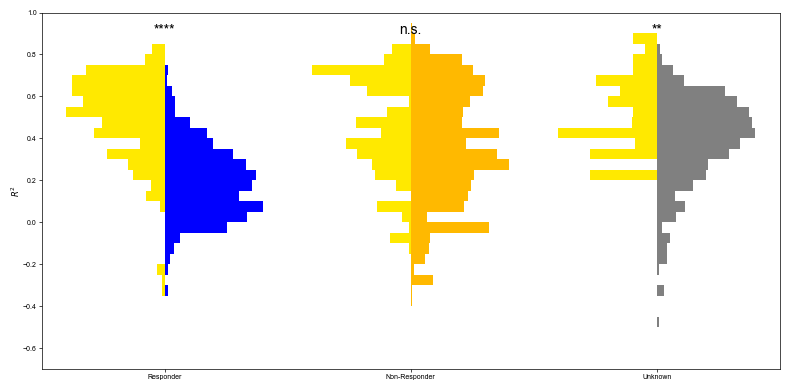

,response_status,n1_raw,n2_raw,dof_raw,t_stat_raw,p_val_raw,ci_raw,hedges_g_raw,hedges_g_ci_raw,n1_neff,n2_neff,dof_neff,t_stat_neff,p_val_neff,ci_neff,hedges_g_neff,hedges_g_ci_neff
0,Responder,183,1615,221.410476,20.329873,1.536741e-52,"(0.27688345533402264, 0.336326797422921)",1.642397,"(1.480432881932341, 1.8043604425292403)",61.281208,331.902844,81.933971,11.431489,1.204783e-18,"(0.2532487682080691, 0.35996148454887456)",1.635944,"(1.3409030665234125, 1.9309847597450784)"
1,Non-Responder,115,1641,131.902029,-1.828591,6.972010e-02,"(-0.08751144562242791, 0.0034373185969622244)",-0.170333,"(-0.3593993622481788, 0.01873333353028736)",38.941446,240.543006,52.153157,-1.018087,3.133362e-01,"(-0.12488618080822439, 0.040812053782758706)",-0.170414,"(-0.5083453589527739, 0.16751638033330063)"
2,Unknown,30,327,36.302438,4.811175,2.625573e-05,"(0.10263242607605094, 0.25213881870077637)",0.820287,"(0.44236342034279297, 1.1982097006603265)",14.038052,67.815909,20.726545,3.090345,5.603856e-03,"(0.05791994320547607, 0.29685130157135126)",0.822272,"(0.23920886797020302, 1.4053352973091977)"


In [18]:
feature = 'lfp_left_OvER_interpolate_R2'
fig, ax = plt.subplots(figsize=(8, 4))
min_val, max_val = df[feature].min(), df[feature].max()
bin_start = np.floor(min_val * 10) / 10
bin_end = np.ceil(max_val * 10) / 10
bin_width = 0.05
bins = np.arange(bin_start, bin_end + bin_width, bin_width)

pooled_results_dict = {'response_status': []}
for corr in ['raw', 'neff']:
    for m in ['n1', 'n2', 'dof', 't_stat', 'p_val', 'ci', 'hedges_g', 'hedges_g_ci']:
        pooled_results_dict[f'{m}_{corr}'] = []

for i, response_status in enumerate(['Responder', 'Non-Responder', 'Unknown']):
    plot_df = df.query('response_status == @response_status')
    plot_df_daily = plot_df.dropna(subset=[feature]).groupby(['pt_id', 'days_since_dbs']).first().reset_index()
    predbs_vals = plot_df_daily.query('state_label_str == "Pre-DBS"')[feature]
    predbs_weights = []
    neff_predbs_total = 0.0
    for pt_id, pt_df in plot_df_daily.groupby('pt_id'):
        pt_predbs = pt_df.query('state_label_str == "Pre-DBS"')
        num_predbs = pt_predbs[feature].shape[0]
        if num_predbs > 0:
            predbs_weights.extend([1 / num_predbs] * num_predbs)
            if num_predbs > 1:
                neff_predbs_total += compute_neff(pt_predbs['days_since_dbs'].values, pt_predbs[feature].values)
            else:
                neff_predbs_total += num_predbs
    postdbs_vals = plot_df_daily.query('state_label_str == @response_status')[feature]
    postdbs_weights = []
    neff_postdbs_total = 0.0
    for pt_id, pt_df in plot_df_daily.groupby('pt_id'):
        pt_postdbs = pt_df.query('state_label_str == @response_status')
        num_postdbs = pt_postdbs[feature].shape[0]
        if num_postdbs > 0:
            postdbs_weights.extend([1 / num_postdbs] * num_postdbs)
            if num_postdbs > 1:
                neff_postdbs_total += compute_neff(pt_postdbs['days_since_dbs'].values, pt_postdbs[feature].values)
            else:
                neff_postdbs_total += num_postdbs

    counts_predbs, _ = np.histogram(predbs_vals, bins=bins, density=True, weights=predbs_weights)
    counts_predbs /= counts_predbs.max() * 2.5
    counts_postdbs, _ = np.histogram(postdbs_vals, bins=bins, density=True, weights=postdbs_weights)
    counts_postdbs /= counts_postdbs.max() * 2.5

    ax.barh(bins[:-1], -counts_predbs, height=bin_width, align='edge', left=i,
            color=COL_PAL['Pre-DBS'], edgecolor=None)
    ax.barh(bins[:-1], counts_postdbs, height=bin_width, align='edge', left=i,
            color=COL_PAL[response_status], edgecolor=None)

    # statistical tests
    if len(predbs_vals) > 1 and len(postdbs_vals) > 1 and not predbs_vals.isna().all() and not postdbs_vals.isna().all():
        n1_raw, n2_raw = len(predbs_vals), len(postdbs_vals)
        raw_stats = welch_stats_with_effect_size(predbs_vals.values, postdbs_vals.values, n1_raw, n2_raw)
        if neff_predbs_total > 1 and neff_postdbs_total > 1:
            neff_stats = welch_stats_with_effect_size(predbs_vals.values, postdbs_vals.values, neff_predbs_total, neff_postdbs_total)
        else:
            neff_stats = dict(_NAN_STATS)
        ax.text(i, bins[-2], get_asterisk_str(neff_stats['p_val']), ha='center', va='top')
        print(f'Pooled stats for {response_status}: t={raw_stats["t_stat"]:.3f}, p={raw_stats["p_val"]:.3g}, dof={raw_stats["dof"]:.1f}, n1={n1_raw}, n2={n2_raw}')
    else:
        raw_stats = dict(_NAN_STATS)
        neff_stats = dict(_NAN_STATS)

    pooled_results_dict['response_status'].append(response_status)
    for corr, stat_dict in [('raw', raw_stats), ('neff', neff_stats)]:
        for m in ['n1', 'n2', 'dof', 't_stat', 'p_val', 'ci', 'hedges_g', 'hedges_g_ci']:
            pooled_results_dict[f'{m}_{corr}'].append(stat_dict[m])

ax.set(
    xlim=(-0.5, 2.5),
    ylim=(bin_start, bin_end),
    ylabel=r'$R^2$',
    xticks=np.arange(3),
    xticklabels=['Responder', 'Non-Responder', 'Unknown'],
)

fig.tight_layout()
plt.savefig('figures/2b.svg', bbox_inches='tight', pad_inches=0)
plt.show()

pooled_df = pd.DataFrame(pooled_results_dict)
pooled_df.to_excel('tables/pooled_stats.xlsx', index=False)
pooled_df

In [19]:
avg_r2s = []
for pt_id, pt_df in df.groupby('pt_id', sort=False):
    avg_r2 = pt_df.dropna(subset=['lfp_left_OvER_interpolate_R2']).groupby('days_since_dbs').first()['lfp_left_OvER_interpolate_R2'].mean()
    if not np.isnan(avg_r2):
        avg_r2s.append(avg_r2)
print(f'Average R^2 across all patients: {np.mean(avg_r2s):.3f} ± {np.std(avg_r2s):.3f}')

Average R^2 across all patients: 0.298 ± 0.166


### 2c and 2d

T-test comparing ΔR² between Responders and Non-Responders: t=-5.495, p=2.820e-03


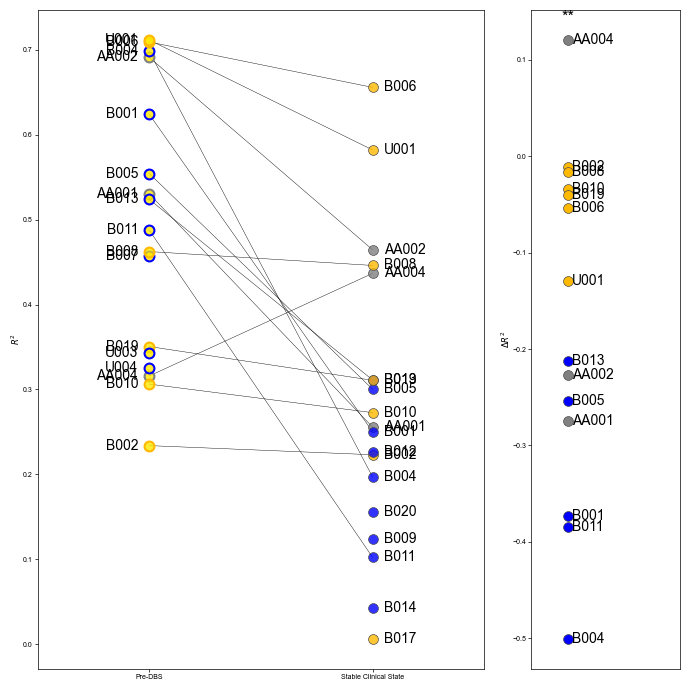

In [20]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(7, 7), width_ratios=[3,1])
side_buffer = 0.5
text_buffer = 0.05
s = 50  # size of the scatter points
alpha = 0.8  # transparency for insides of the scatter points
    
feature = f'lfp_left_OvER_interpolate_R2'
postdbs_query_string = f'(days_since_dbs > 0) and (state_label_str in ["Unknown", "Responder", "Non-Responder"])'
clothesline_df = df.dropna(subset=[feature, 'response_status', 'state_label_str'], how='any').copy()

r_deltas, nr_deltas = [], []
for pt_id, pt_df in clothesline_df.groupby('pt_id'):
    pre_dbs_y = pt_df.query(f'state_label_str == "Pre-DBS"')[feature].mean()
    response_state = pt_df['response_status'].iloc[0]
    post_dbs_y = pt_df.query(postdbs_query_string)[feature].mean()
    delta_y = post_dbs_y - pre_dbs_y
    axs[0].scatter(0, pre_dbs_y, marker='o', color=add_alpha_to_color(COL_PAL['Pre-DBS'], alpha), s=s, edgecolors=COL_PAL[response_state], lw=1.5)
    axs[0].scatter(1, post_dbs_y, marker='o', color=add_alpha_to_color(COL_PAL[response_state], alpha), s=s, edgecolors='#4c4c4c', lw=0.5)
    axs[0].plot([0, 1], [pre_dbs_y, post_dbs_y], c='k', lw=0.3, zorder=0)
    axs[0].text(0-text_buffer, pre_dbs_y, pt_id, ha='right', va='center')
    axs[0].text(1+text_buffer, post_dbs_y, pt_id, ha='left', va='center')

    axs[1].scatter(0, delta_y, marker='o', color=COL_PAL[response_state], s=s, edgecolors='#4c4c4c', lw=0.5)
    axs[1].text(0+text_buffer, delta_y, pt_id, ha='left', va='center')
    if not np.isnan(delta_y):
        match response_state:
            case 'Responder':
                r_deltas.append(delta_y)
            case 'Non-Responder':
                nr_deltas.append(delta_y)

t_stat, p_val = stats.ttest_ind(r_deltas, nr_deltas, equal_var=False)
print(f'T-test comparing ΔR² between Responders and Non-Responders: t={t_stat:.3f}, p={p_val:.3e}')
axs[1].text(0, axs[1].get_ylim()[1], get_asterisk_str(p_val), ha='center', va='top', fontsize=8*1.5, color='k')
axs[0].set(
    xticks=[0, 1],
    xticklabels=['Pre-DBS', 'Stable Clinical State'],
    ylabel=r'$R^2$',
    xlim=[-side_buffer, 1 + side_buffer],
)
axs[1].set(
    xticks=[],
    xlim=[-side_buffer, 1 + side_buffer],
    ylabel=r'$\Delta R^2$'
)

fig.tight_layout()
plt.savefig('figures/2c_d.svg', bbox_inches='tight', pad_inches=0)
plt.show()

### 2e

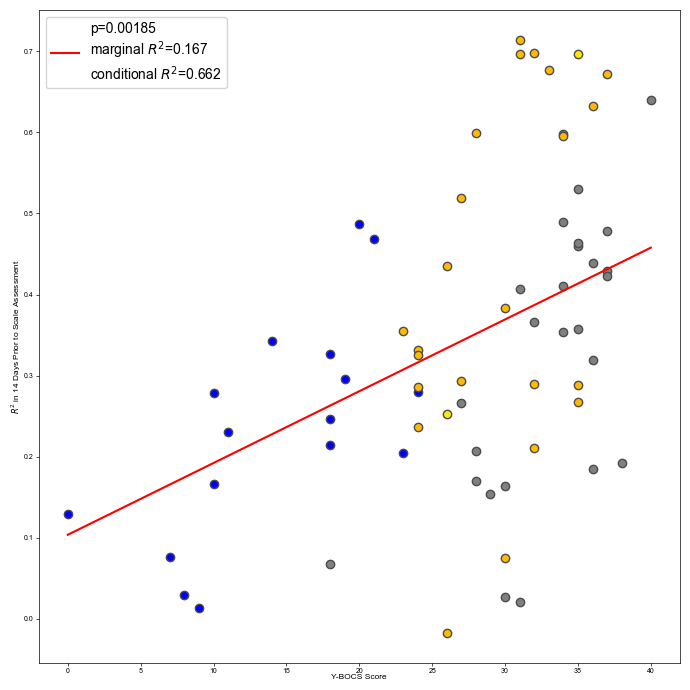

In [64]:
fig, ax = plt.subplots(figsize=(7,7))
xs, ys, pt_ids = [], [], []

feature = 'lfp_left_OvER_interpolate_R2'
for pt_id, pt_df in df.groupby('pt_id'):
    pt_scale_df = scale_df.query('pt_id == @pt_id').copy()
    pt_df_daily = pt_df.dropna(subset=[feature]).groupby('days_since_dbs').head(1)
    for ind, scale_row in pt_scale_df.iterrows():
        scale_day = scale_row['days_since_dbs']
        scale_val = scale_row['YBOCS']

        try:
            clinical_status = pt_df.query('days_since_dbs <= @scale_day')['state_label_str'].iloc[-1]
        except IndexError:
            clinical_status = 'Pre-DBS'

        window_start = scale_day - 14
        window_end = scale_day
        if (scale_day - 14) < pt_df['days_since_dbs'].iloc[0]:
            continue

        r2_14d_prior_avg = pt_df_daily.query('@window_start < days_since_dbs <= @window_end')[feature].mean()
        if pd.isna(r2_14d_prior_avg):
            continue

        color = COL_PAL[clinical_status]
        ax.scatter(scale_val, r2_14d_prior_avg, color=color, lw=1, ec='#4c4c4c')
        xs.append(scale_val)
        ys.append(r2_14d_prior_avg)
        pt_ids.append(pt_id)

yb_scores = np.array(xs)
r2_14d_prior = np.array(ys)

mm_df = pd.DataFrame({
    'YBOCS': yb_scores,
    'r2': r2_14d_prior,
    'pt_id': pt_ids,
})

mdl = smf.mixedlm("r2 ~ YBOCS", data=mm_df, groups="pt_id", re_formula="~1")
result = mdl.fit()

slope = result.fe_params['YBOCS']
intercept = result.fe_params['Intercept']
p_value = result.pvalues['YBOCS']

fe_pred = result.predict(mm_df)
fixed_var = np.var(fe_pred, ddof=1)
random_var = float(result.cov_re.iloc[0, 0])
resid_var = result.scale
marginal_r2 = fixed_var / (fixed_var + random_var + resid_var)
conditional_r2 = (fixed_var + random_var) / (fixed_var + random_var + resid_var)

line_xs = np.array([yb_scores.min(), yb_scores.max()])
line_ys = intercept + slope * line_xs

ax.plot(line_xs, line_ys, color='red',
        label=f'p={p_value:.3g}\nmarginal $R^2$={marginal_r2:.3f}\nconditional $R^2$={conditional_r2:.3f}')
ax.legend()
ax.set(
    xlabel='Y-BOCS Score',
    ylabel=r'$R^2$ in 14 Days Prior to Scale Assessment',
)

fig.tight_layout()
plt.savefig('figures/2e.svg', bbox_inches='tight', pad_inches=0)
plt.show()

## Figure 3

In [22]:
# Calculate delta features based on pre-DBS means
features = ['lfp_R2', 'cosinor_amplitude']
for feature in features:
    if feature.startswith('lfp_'):
        feature_col = f'lfp_left_OvER_interpolate_{feature[4:]}'
    else:
        feature_col = f'left_{feature}'
    
    pre_dbs_means = (
        df.query('days_since_dbs < 0')
        .groupby('pt_id')[feature_col]
        .mean()
        .rename(f'pre_dbs_mean_{feature_col}')
        .reset_index()
    )
    df = df.merge(pre_dbs_means, on='pt_id', how='left')
    df[f'delta_{feature_col}'] = df[feature_col] - df[f'pre_dbs_mean_{feature_col}']
    df.drop(columns=[f'pre_dbs_mean_{feature_col}'], inplace=True)

# Delta-normalize acrophase features using circular mean of pre-DBS values
acrophase_cols = [c for c in df.columns if 'acrophase' in c]
for feature_col in acrophase_cols:
    if feature_col.endswith('_rad'):
        period = 2 * np.pi
    elif feature_col.endswith('_hr'):
        period = 24
    
    pre_dbs_means = (
        df.query('days_since_dbs < 0')
        .groupby('pt_id')[feature_col]
        .agg(lambda x: stats.circmean(x.dropna(), high=period, low=0) if x.notna().any() else np.nan)
        .rename(f'pre_dbs_mean_{feature_col}')
        .reset_index()
    )
    df = df.merge(pre_dbs_means, on='pt_id', how='left')
    df[f'delta_{feature_col}'] = ((df[feature_col] - df[f'pre_dbs_mean_{feature_col}'] + (period / 2)) % period) - (period / 2)
    df.drop(columns=[f'pre_dbs_mean_{feature_col}'], inplace=True)

In [23]:
window_widths = [1, 3, 5, 7, 14, 21, 28]
features = ['R2', 'delta_R2']
hem = 'left'  # change to 'right' to run this for the other hemisphere

# container for all per-day results across pts and features
per_day_results = []

for feature in features:
    if feature.startswith('delta_'):
        feature_col = f'delta_lfp_{hem}_OvER_interpolate_{feature[6:]}'
    else:
        feature_col = f'lfp_{hem}_OvER_interpolate_{feature}'

    # single row per day per patient
    day_df = df.dropna(subset=[feature_col]).groupby(['pt_id', 'days_since_dbs'], as_index=False).first()
    if day_df.empty:
        continue

    results = []
    for pt_id, pt_day_df in day_df.groupby('pt_id', sort=False):
        days = pt_day_df['days_since_dbs'].to_numpy()
        values = pt_day_df[feature_col].to_numpy()
        rolling_matrix = group_calendar_rolling(days, values, window_widths)
        cols = {f'{hem}_{feature}_rolling_avg_{w}d': rolling_matrix[:, i]
                for i, w in enumerate(window_widths)}
        res_df = pt_day_df[['pt_id', 'days_since_dbs']].copy()
        for cname, arr in cols.items():
            res_df[cname] = arr
        results.append(res_df)

    if results:
        all_res = pd.concat(results, ignore_index=True)
        per_day_results.append(all_res)

if per_day_results:
    per_day_df = pd.concat(per_day_results, ignore_index=True)
    per_day_df = per_day_df.groupby(['pt_id', 'days_since_dbs']).first().reset_index()
    df = df.merge(per_day_df, on=['pt_id', 'days_since_dbs'], how='left', suffixes=('', '_perday'))

100%|██████████| 7/7 [00:03<00:00,  1.94it/s]


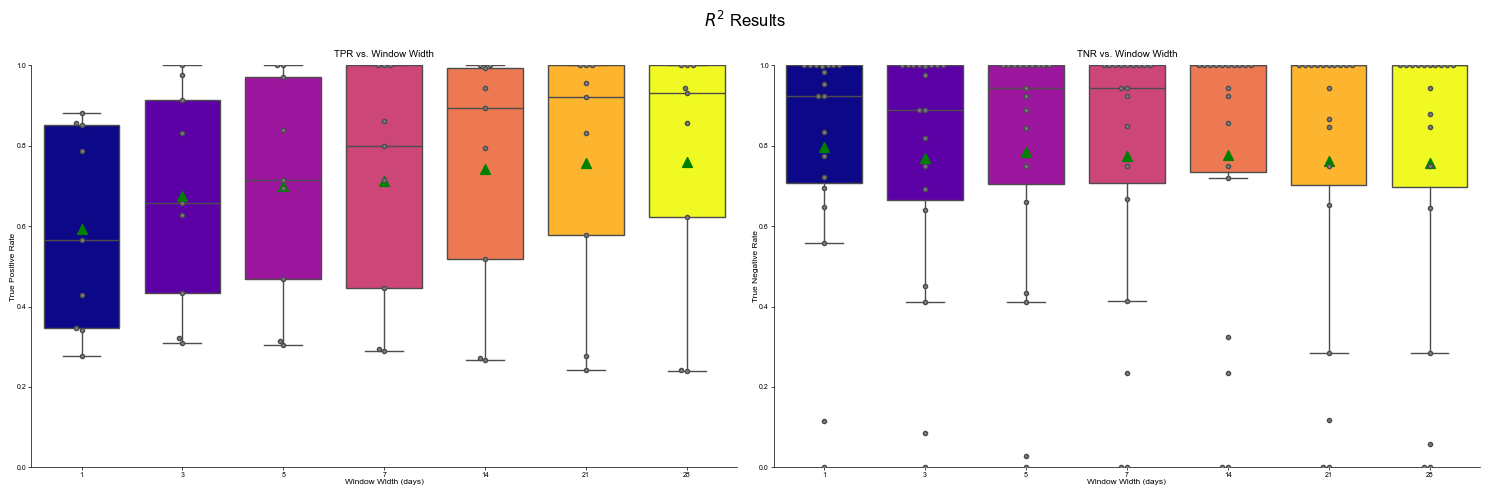

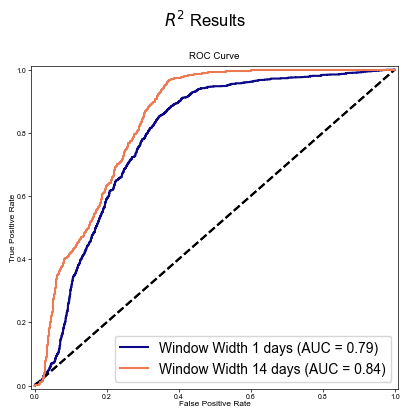

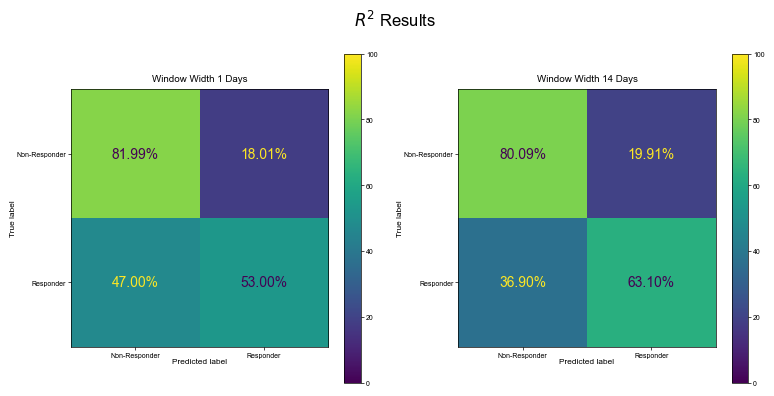

100%|██████████| 7/7 [00:03<00:00,  2.03it/s]


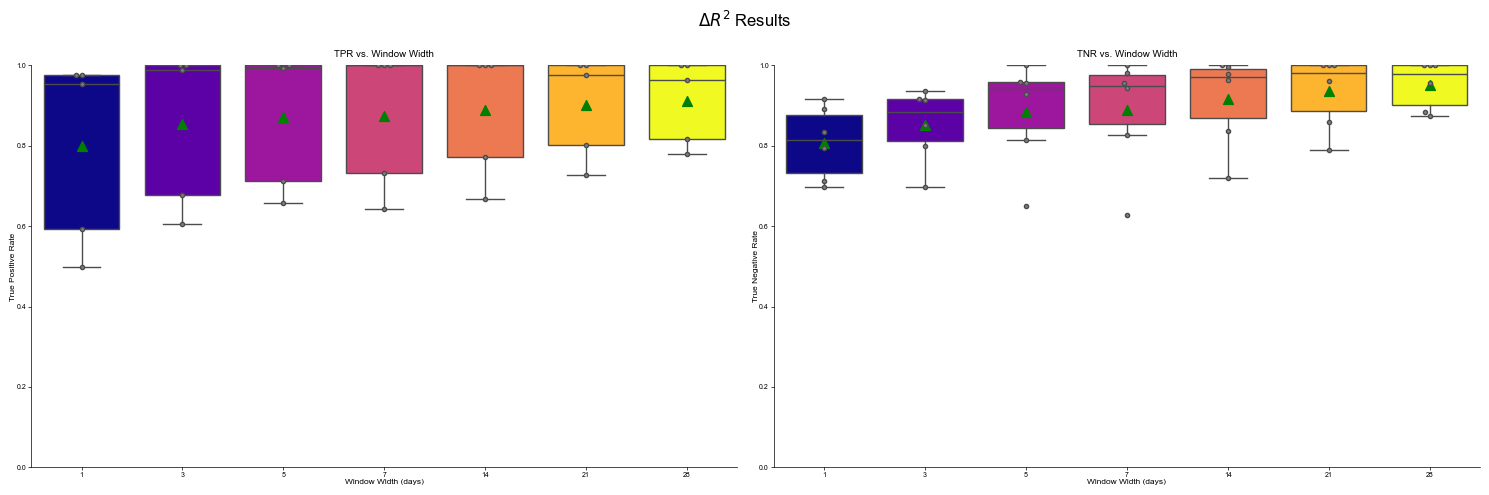

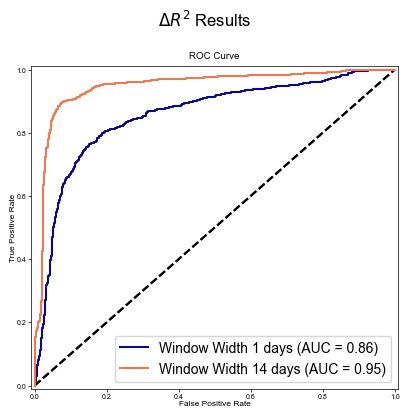

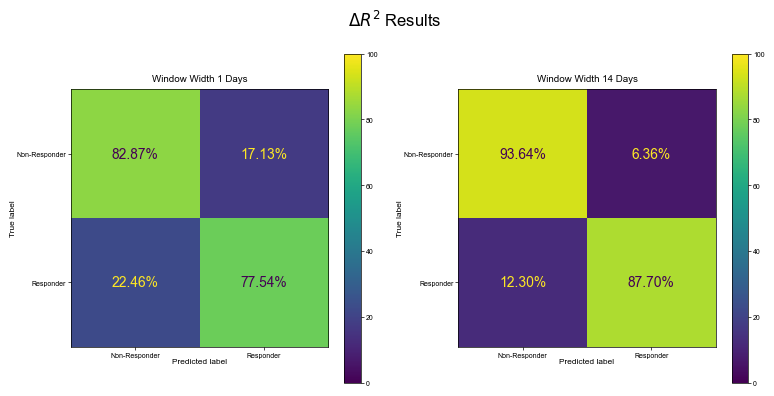

In [24]:
# Plot performance metrics for different window widths of the R2 and delta R2 features
daily_df = df.groupby(by=['pt_id', 'days_since_dbs']).head(1)
operating_points = [0.66, 0.5]
window_widths = [1, 3, 5, 7, 14, 21, 28]

cmap = plt.get_cmap('plasma')
positions = np.linspace(0, 1, len(window_widths))
hex_codes = [mpl.colors.to_hex(cmap(pos)) for pos in positions]

get_model_features = [lambda w: f'left_R2_rolling_avg_{w}d', lambda w: f'left_delta_R2_rolling_avg_{w}d']
model_results_subfolders = ['R2_results', 'delta_R2_results']
for i, (get_model_feature, model_results_subfolder, op) in enumerate(zip(get_model_features, model_results_subfolders, operating_points)):
    boxplot_fig, boxplot_axs = plt.subplots(ncols=2, figsize=(15,5))
    roc_fig, roc_ax = plt.subplots(figsize=(4.2, 4.2))
    conf_mat_fig, conf_mat_axs = plt.subplots(ncols=2, figsize=(8,4))

    boxplot_axs, roc_ax, conf_mat_axs = plot_model_metrics(
        df, get_model_feature, window_widths,
        boxplot_axs=boxplot_axs, roc_ax=roc_ax, conf_mat_axs=conf_mat_axs,
        operating_point=op, boxcolors=hex_codes, swarmcolors=['#808080']*len(window_widths)
    )
    [fig.suptitle((r'$\Delta R^2$' if 'delta' in model_results_subfolder.lower() else r'$R^2$') + ' Results') for fig in [boxplot_fig, roc_fig, conf_mat_fig]]
    [fig.tight_layout() for fig in [boxplot_fig, roc_fig, conf_mat_fig]]

    [ax.spines[['right', 'top']].set_visible(False) for ax in boxplot_axs]

    boxplot_fig.savefig(f'figures/3{chr(ord("a") + i*4)}_{chr(ord("b") + i*4)}.svg', bbox_inches='tight', pad_inches=0)
    roc_fig.savefig(f'figures/3{chr(ord("c") + i*4)}.svg', bbox_inches='tight', pad_inches=0)
    conf_mat_fig.savefig(f'figures/3{chr(ord("d") + i*4)}.svg', bbox_inches='tight', pad_inches=0)
    plt.show()

## Figure 4

### 4a and 4b

In [25]:
# Run logistic regression model and evaluate performance
model_features = ['delta_lfp_left_OvER_interpolate_R2']
daily_df = df.dropna(subset=model_features, how='any').groupby(['pt_id', 'days_since_dbs']).head(1)

results, pt_results, overall_model = leave_one_patient_out_logistic_regression(
    daily_df,
    model_features,
)

# Display per-patient and aggregated logistic regression model results
pt_results_list = []
for pt_id, pt_res in pt_results.items():
    response = df.query('pt_id == @pt_id').iloc[0]['response_status']
    conf_mat = pt_res.get('confusion_matrix', None)
    if conf_mat is not None:
        tn, fp, fn, tp = conf_mat.ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        tnr = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    else:
        tpr = np.nan
        tnr = np.nan
    
    try:
        w0, w1 = pt_res['model'].named_steps["logreg"].intercept_[0], pt_res['model'].named_steps["logreg"].coef_[0][0]
    except AttributeError:
        w0, w1 = np.nan, np.nan
    pt_results_list.append({
        'pt_id': pt_id,
        'raw_accuracy': pt_res.get('raw_accuracy', np.nan),
        'AUC': pt_res.get('auc', np.nan),
        'balanced_accuracy': pt_res.get('balanced_accuracy', np.nan),
        'TPR': tpr,
        'TNR': tnr,
        'confusion_matrix': conf_mat,
        'R/NR': response,
        'w0': w0,
        'w1': w1,
    })

overall_conf_mat = results.get('confusion_matrix', None)
if overall_conf_mat is not None:
    tn, fp, fn, tp = overall_conf_mat.ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    tnr = tn / (tn + fp) if (tn + fp) > 0 else np.nan
else:
    tpr = np.nan
    tnr = np.nan

state_counts = df.groupby('pt_id').first()['response_status'].value_counts()
num_responders = state_counts.get('Responder', 0)
num_nonresponders = state_counts.get('Non-Responder', 0)
num_unknown = state_counts.get('Unknown', 0)
num_clinically_labeled = num_responders + num_nonresponders
num_pts = len(pt_results_list)
overall_w0 = overall_model.named_steps["logreg"].intercept_[0]
overall_w1 = overall_model.named_steps["logreg"].coef_[0][0]
overall_threshold = -overall_w0 / overall_w1 if overall_w1 != 0 else np.nan
pt_results_list.append({
    'pt_id': 'OVERALL',
    'raw_accuracy': results.get('raw_accuracy', np.nan),
    'AUC': results.get('AUC', np.nan),
    'balanced_accuracy': results.get('balanced_accuracy', np.nan),
    'TPR': tpr,
    'TNR': tnr,
    'confusion_matrix': overall_conf_mat,
    'R/NR': f'{num_responders}/{num_clinically_labeled} Responders',
    'threshold': overall_threshold,
    'w0': overall_w0,
    'w1': overall_w1,
})

weighted_conf_mat = results.get('weighted_confusion_matrix', None)
if weighted_conf_mat is not None:
    tn, fp, fn, tp = weighted_conf_mat.ravel()
    tpr_weighted = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    tnr_weighted = tn / (tn + fp) if (tn + fp) > 0 else np.nan
else:
    tpr_weighted = np.nan
    tnr_weighted = np.nan
num_samples_dict = [daily_df.query('pt_id == @pt_id').shape[0] for pt_id in [pt_result['pt_id'] for pt_result in pt_results_list[:-1]]]
pt_results_list.append({
    'pt_id': 'WEIGHTED OVERALL',
    'raw_accuracy': results.get('weighted_raw_accuracy', np.nan),
    'AUC': results.get('weighted_AUC', np.nan),
    'balanced_accuracy': results.get('weighted_balanced_accuracy', np.nan),
    'TPR': tpr_weighted,
    'TNR': tnr_weighted,
    'confusion_matrix': weighted_conf_mat,
    'R/NR': f'{num_responders / num_clinically_labeled * 100:.1f}% Responders',
    'threshold': overall_threshold,
    'w0': overall_w0,
    'w1': overall_w1,
})

pt_results_df = pd.DataFrame(pt_results_list)
pt_results_df['threshold'] = -pt_results_df['w0'] / pt_results_df['w1']
pt_results_df = pt_results_df[['pt_id', 'R/NR', 'raw_accuracy', 'AUC', 'balanced_accuracy', 'TPR', 'TNR', 'threshold', 'confusion_matrix', 'w0', 'w1']]

pt_results_df

,pt_id,R/NR,raw_accuracy,AUC,balanced_accuracy,TPR,TNR,threshold,confusion_matrix,w0,w1
0,AA001,Unknown,NaN,NaN,NaN,NaN,NaN,-0.176690,None,-1.543178,-8.733823
1,AA002,Unknown,NaN,NaN,NaN,NaN,NaN,-0.176813,None,-1.542448,-8.723630
2,AA004,Unknown,NaN,NaN,NaN,NaN,NaN,-0.176757,None,-1.543069,-8.729875
3,B001,Responder,0.975610,NaN,NaN,0.975610,NaN,-0.172971,"[[0, 0], [4, 160]]",-1.408533,-8.143178
4,B002,Non-Responder,0.916667,NaN,NaN,NaN,0.916667,-0.176695,"[[11, 1], [0, 0]]",-1.546342,-8.751459
5,B004,Responder,0.953416,NaN,NaN,0.953416,NaN,-0.157468,"[[0, 0], [15, 307]]",-1.294968,-8.223669
6,B005,Responder,0.592208,NaN,NaN,0.592208,NaN,-0.199148,"[[0, 0], [157, 228]]",-1.896805,-9.524609
7,B006,Non-Responder,0.890724,NaN,NaN,NaN,0.890724,-0.178344,"[[701, 86], [0, 0]]",-1.317588,-7.387889
8,B007,Responder,NaN,NaN,NaN,NaN,NaN,-0.176738,None,-1.544500,-8.738907
9,B008,Non-Responder,0.712251,NaN,NaN,NaN,0.712251,-0.170826,"[[250, 101], [0, 0]]",-1.741937,-10.197132


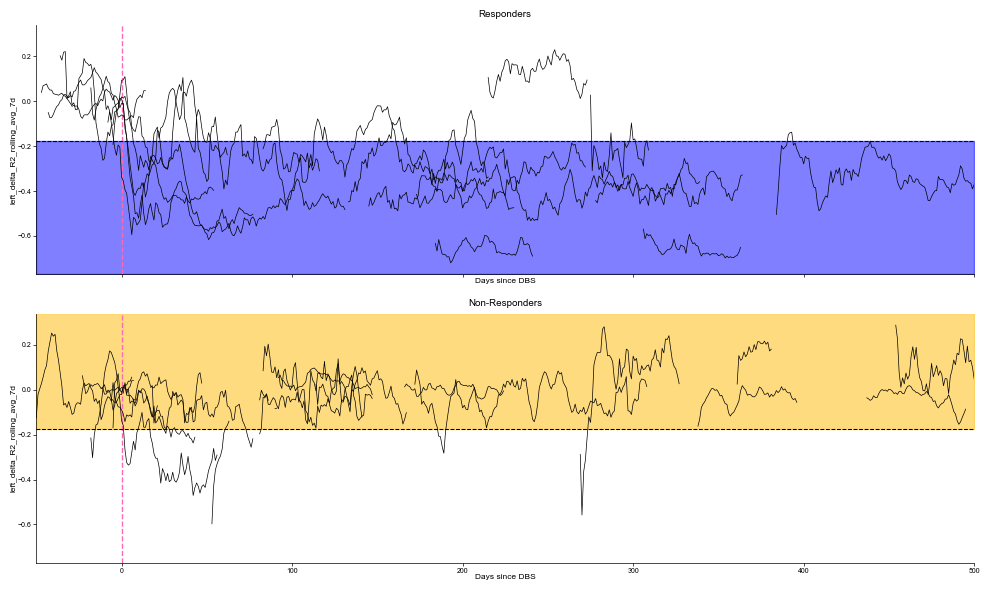

In [26]:
feature = 'left_delta_R2_rolling_avg_7d'
fig, axs = plt.subplots(nrows=2, figsize=(10, 6), sharey='all', sharex=True)

for ax in axs:
    ax.set(
        xlabel='Days since DBS',
        ylabel=feature,
    )
    ax.axvline(0, 0, 1, color='#ff69b4', ls='--', lw=1, label='DBS On', zorder=2)

overall_avg_threshold = pt_results_df.query('pt_id == "OVERALL"')['threshold'].iloc[0]
r_avg_threshold = pt_results_df.loc[pt_results_df['R/NR'] == 'Responder', 'threshold'].mean()
nr_avg_threshold = pt_results_df.loc[pt_results_df['R/NR'] == 'Non-Responder', 'threshold'].mean()
plotted_r_pts = []

min_day = 1000
for pt_id, pt_df in df.dropna(subset=[feature]).groupby('pt_id', sort=False):
    plot_df = pt_df.query('days_since_dbs <= 500').copy()
    if pt_df[feature].isna().all():
        continue
    response_status = pt_df['response_status'].iloc[0]
    if response_status == 'Responder':
        ax = axs[0]
        ax.set_title('Responders')
    elif response_status == 'Non-Responder':
        ax = axs[1]
        ax.set_title('Non-Responders')
    else:
        continue
    
    unique_states = pt_df['state_label_str'].unique()
    if not ('Pre-DBS' in pt_df['state_label_str'].unique() and ((response_status in unique_states) or ('Transition' in unique_states))):
        continue

    if response_status == 'Responder':
        plotted_r_pts.append(pt_id)
    min_day = min(min_day, plot_df['days_since_dbs'].min())
    pt_df_daily = plot_df.dropna(subset=[feature]).groupby('days_since_dbs').head(1)
    days = pt_df_daily['days_since_dbs']
    day_diffs = np.diff(days)
    breaks = np.where(day_diffs > 1)[0] + 1
    segments = np.split(np.arange(len(days)), breaks)
    vals = pt_df_daily[feature]

    for seg in segments:
        ax.plot(pt_df_daily['days_since_dbs'].iloc[seg], pt_df_daily[feature].iloc[seg],
                c='k', lw=0.5, zorder=5)

axs[0].axhline(r_avg_threshold, color='k', ls='--', lw=0.75, zorder=3)
axs[1].axhline(nr_avg_threshold, color='k', ls='--', lw=0.75, zorder=3)
axs[0].set_xlim(min_day, 500)
xlims, ylims = axs[0].get_xlim(), axs[0].get_ylim()
axs[0].fill_between(xlims, r_avg_threshold, axs[0].get_ylim()[0], color=COL_PAL['Responder'], alpha=0.5, zorder=0)
axs[1].fill_between(xlims, nr_avg_threshold, axs[1].get_ylim()[1], color=COL_PAL['Non-Responder'], alpha=0.5, zorder=0)
axs[0].set(xlim=xlims, ylim=ylims)
[ax.spines[['top', 'right']].set_visible(False) for ax in axs]

fig.tight_layout()
fig.savefig('figures/4a_b.svg', bbox_inches='tight', pad_inches=0)
plt.show()

### 4c

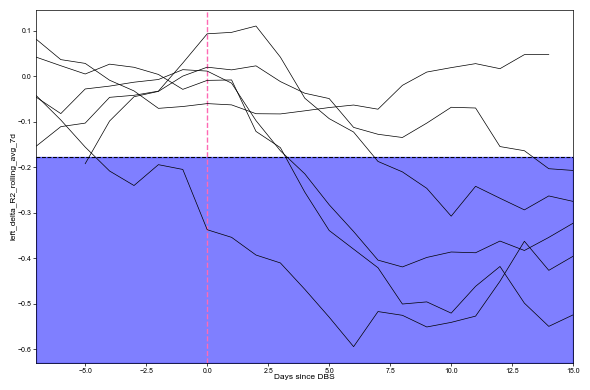

In [27]:
start_day, end_day = -7, 15 # both ends inclusive
feature = 'left_delta_R2_rolling_avg_7d'
fig, ax = plt.subplots(figsize=(6, 4))
ax.axvline(0, 0, 1, color='#ff69b4', ls='--', lw=1, label='DBS On', zorder=2)
for pt_id in plotted_r_pts:
    pt_df = df.query('pt_id == @pt_id').copy()
    plot_df = pt_df.query('@start_day <= days_since_dbs <= @end_day').copy()
    if plot_df[feature].isna().all():
        continue
    response_status = pt_df['response_status'].iloc[0]
    if response_status != 'Responder':
        continue

    pt_df_daily = plot_df.dropna(subset=[feature]).groupby('days_since_dbs').head(1)
    ax.plot(pt_df_daily['days_since_dbs'], pt_df_daily[feature],
            c='k', lw=0.5, zorder=5)
ax.axhline(r_avg_threshold, color='k', ls='--', lw=0.75, zorder=3)
xlims, ylims = ax.get_xlim(), ax.get_ylim()
ax.fill_between([start_day, end_day], r_avg_threshold, ax.get_ylim()[0], color=COL_PAL['Responder'], alpha=0.5, zorder=0)
ax.set(
    xlim=[start_day, end_day],
    ylim=ylims,
    xlabel='Days since DBS',
    ylabel=feature
)

fig.tight_layout()
fig.savefig('figures/4c.svg', bbox_inches='tight', pad_inches=0)
plt.show()

### 4d

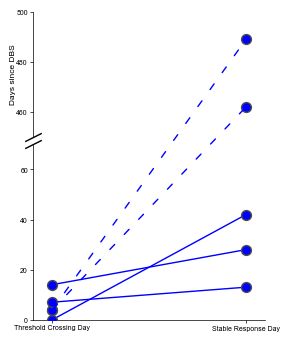

In [28]:
fig, (top_ax, bot_ax) = plt.subplots(nrows=2, figsize=(3, 4), height_ratios=[1, 7/5],)
# This figure is split into two subplots because we had one responder who responded
# much later than the rest. For generalized data, this plot is probably better
# represented with a single plot, which is trivially made.
fig.subplots_adjust(hspace=0.05)
crossing_days, response_days = [], []
for pt_id in plotted_r_pts:
    pt_df = df.query('pt_id == @pt_id').copy()
    pt_scale_df = scale_df.query('pt_id == @pt_id').copy()
    try:
        threshold_crossing_day = pt_df.query('days_since_dbs >= 0 and left_delta_R2_rolling_avg_7d <= @r_avg_threshold').iloc[0]['days_since_dbs']
    except IndexError:
        continue
    response_days_since_dbs = pt_scale_df.query('is_clinical_response').iloc[0]['days_since_dbs']
    if pt_id == "B001":
        response_days_since_dbs = pt_scale_df.query('is_clinical_response').iloc[1]['days_since_dbs'] # relapse case; initial response was not stable
    crossing_days.append(threshold_crossing_day)
    response_days.append(response_days_since_dbs)

    top_ax.scatter(0, threshold_crossing_day, marker='o', label=pt_id, color=COL_PAL['Responder'], zorder=5, ec='#4c4c4c', lw=1, s=50)
    bot_ax.scatter(0, threshold_crossing_day, marker='o', label=pt_id, color=COL_PAL['Responder'], zorder=5, ec='#4c4c4c', lw=1, s=50)
    top_ax.scatter(1, response_days_since_dbs, marker='o', label=pt_id, color=COL_PAL['Responder'], zorder=5, ec='#4c4c4c', lw=1, s=50)
    bot_ax.scatter(1, response_days_since_dbs, marker='o', label=pt_id, color=COL_PAL['Responder'], zorder=5, ec='#4c4c4c', lw=1, s=50)
    if response_days_since_dbs < 460:
        bot_ax.plot([0, 1], [threshold_crossing_day, response_days_since_dbs],
                    c=COL_PAL['Responder'], lw=1, zorder=4)
    else:
        threshold_crossing_day_ax = top_ax.transData.transform((0, threshold_crossing_day))[1]
        response_day_ax = bot_ax.transData.transform((1, response_days_since_dbs))[1]
        con = mpl.patches.ConnectionPatch(xyA=(0, threshold_crossing_day), xyB=(1, response_days_since_dbs),
                              coordsA='data', coordsB='data',
                              axesA=bot_ax, axesB=top_ax,
                              color=COL_PAL['Responder'], lw=1, ls=(0, (5, 10)), zorder=4)
        fig.add_artist(con)
top_ax.set(
    xlim=[-0.1, 1.1],
    xticks=[],
    ylabel='Days since DBS',
    ylim=[450, 500],
    yticks=[460, 480, 500],
)
bot_ax.set(
    xlim=[-0.1, 1.1],
    xticks=[0, 1],
    xticklabels=['Threshold Crossing Day', 'Stable Response Day'],
    ylim=[0, 70],
    yticks=[0, 20, 40, 60]
)
top_ax.spines[['top', 'right', 'bottom']].set_visible(False)
bot_ax.spines[['top', 'right']].set_visible(False)

d = .5
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12,
              linestyle="none", color='k', mec='k', mew=1, clip_on=False)
top_ax.plot([0], [0], transform=top_ax.transAxes, **kwargs)
bot_ax.plot([0], [1], transform=bot_ax.transAxes, **kwargs)

fig.savefig('figures/4d.svg', bbox_inches='tight', pad_inches=0)
plt.show()

### 4e

T-test comparing % of post-DBS days above threshold between Responders and Non-Responders: t=-6.612, p=2.259e-04


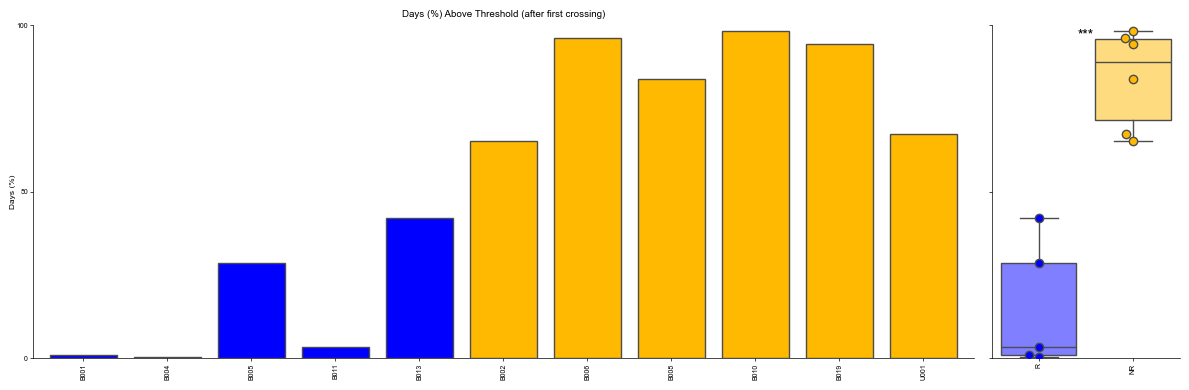

In [29]:
feature = 'left_delta_R2_rolling_avg_7d'

nr_pts, nr_vals = [], []
r_pts, r_vals = [], []
pct_below_dict = {'pt_id': [], 'pct_below_threshold': []}

for pt_id, postdbs_pt_df in df.dropna(subset=feature).query('days_since_dbs > 0').groupby(['pt_id', 'days_since_dbs']).head(1).groupby('pt_id'):
    if postdbs_pt_df.empty:
        continue
    response_status = postdbs_pt_df['response_status'].iloc[0]

    threshold = pt_results_df.query('pt_id == @pt_id')['threshold'].iloc[0]
    feature_vals = postdbs_pt_df[feature].values

    if response_status == 'Responder':
        first_crossing_sample = np.where(feature_vals <= threshold)[0]
        if len(first_crossing_sample) > 0:
            first_crossing_sample = first_crossing_sample[0]
        else:
            continue
        postdbs_pt_df = postdbs_pt_df.iloc[first_crossing_sample:]
    
    pct_above_thresh = np.mean(feature_vals > threshold)
    pct_below_thresh = np.mean(feature_vals < threshold)
    pct_below_dict['pt_id'].append(pt_id)
    pct_below_dict['pct_below_threshold'].append(pct_below_thresh)

    if response_status == 'Responder':
        r_pts.append(pt_id)
        r_vals.append(pct_above_thresh)
    elif response_status == 'Non-Responder':
        nr_pts.append(pt_id)
        nr_vals.append(pct_above_thresh)

nr_vals, r_vals = np.array(nr_vals), np.array(r_vals)
fig, axs = plt.subplots(ncols=2, figsize=(12, 4), width_ratios=[5, 1], sharey=True)
axs[0].bar(np.arange(len(r_pts)), r_vals*100, color=COL_PAL['Responder'], edgecolor='#4c4c4c', lw=1, width=0.8, zorder=5)
axs[0].bar(np.arange(len(nr_pts)) + len(r_pts), nr_vals*100, color=COL_PAL['Non-Responder'], edgecolor='#4c4c4c', lw=1, width=0.8, zorder=5)
axs[0].set(
    ylabel='Days (%)',
    xticks=np.arange(len(r_pts) + len(nr_pts)),
    title='Days (%) Above Threshold (after first crossing)',
    ylim=(0, 100),
    xlim=[-0.6, len(r_pts) + len(nr_pts) - 0.4],
    yticks=[0, 50, 100],
)
axs[0].set_xticklabels(r_pts + nr_pts, rotation=90, ha='center', va='top')
axs[0].spines[['top', 'right']].set_visible(False)

plot_box_and_swarmplot(0, r_vals*100, axs[1], COL_PAL['Responder'], alpha=0.5, widths=0.8)
plot_box_and_swarmplot(1, nr_vals*100, axs[1], COL_PAL['Non-Responder'], alpha=0.5, widths=0.8)

t_stat, p_val = stats.ttest_ind(r_vals, nr_vals, equal_var=False)
print(f'T-test comparing % of post-DBS days above threshold between Responders and Non-Responders: t={t_stat:.3f}, p={p_val:.3e}')
axs[1].text(0.5, 0.99, get_asterisk_str(p_val), ha='center', va='top', transform=axs[1].transAxes)

axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(['R', 'NR'],
                       rotation=90, ha='center', va='top')
axs[1].spines[['top', 'right']].set_visible(False)
axs[1].set_xlim(-0.5, 1.5)

fig.tight_layout()
fig.savefig('figures/4e.svg', bbox_inches='tight', pad_inches=0)
plt.show()

### 4f

T-test between responders and non-responders: t=-3.07, p=1.697e-02


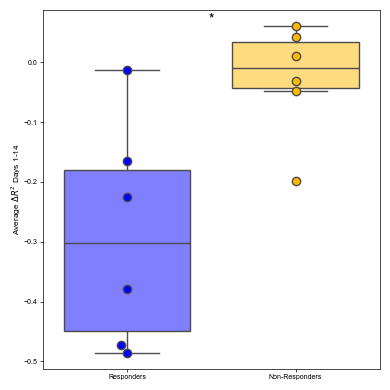

In [30]:
feature = 'delta_lfp_left_OvER_interpolate_R2'
box_stats = pd.DataFrame(columns=['pt_id', 'response_status', 'first_14d_avg_delta_R2'])
r_vals, nr_vals = [], []
for pt_id, pt_df in df.dropna(subset=[feature]).groupby('pt_id'):
    response_status = pt_df['response_status'].iloc[0]

    first_14d_df = pt_df.query('days_since_dbs > 0 and days_since_dbs <= 14').groupby('days_since_dbs').head(1)
    first_14d_avg_feature = first_14d_df[feature].mean()

    box_stats.loc[len(box_stats)] = [pt_id, response_status, first_14d_avg_feature]

    if pd.isna(first_14d_avg_feature):
            continue
    if response_status == 'Unknown':
            continue
    if response_status == 'Responder':
        r_vals.append(first_14d_avg_feature)
    else:
        nr_vals.append(first_14d_avg_feature)

fig, ax = plt.subplots(figsize=(4, 4))

plot_box_and_swarmplot(0, r_vals, ax, color=COL_PAL['Responder'])
plot_box_and_swarmplot(1, nr_vals, ax, color=COL_PAL['Non-Responder'])

t_stat, p_val = stats.ttest_ind(r_vals, nr_vals, equal_var=False)
max_r_val = max(r_vals) if r_vals else float('-inf')
max_nr_val = max(nr_vals) if nr_vals else float('-inf')
ax.text(0.5, max(max_r_val, max_nr_val), get_asterisk_str(p_val), ha='center', va='bottom')
print(f'T-test between responders and non-responders: t={t_stat:.3g}, p={p_val:.3e}')

ax.set(
    xticks=[0, 1],
    xticklabels=['Responders', 'Non-Responders'],
    ylabel=r'Average $\Delta R^2$ Days 1-14'
)

fig.tight_layout()
fig.savefig('figures/4f.svg', bbox_inches='tight', pad_inches=0)
box_stats.to_excel('tables/first_14d_avg_delta_R2.xlsx', index=False)
plt.show()

### 4g and 4h

T-test comparing left hemisphere stimulation amplitudes between Responders and Non-Responders: t=-2.184, p=6.424e-02
T-test comparing right hemisphere stimulation amplitudes between Responders and Non-Responders: t=-1.317, p=2.563e-01
T-test comparing left hemisphere stimulation pulse widths between Responders and Non-Responders: t=0.632, p=5.454e-01
T-test comparing right hemisphere stimulation pulse widths between Responders and Non-Responders: t=-1.633, p=1.778e-01


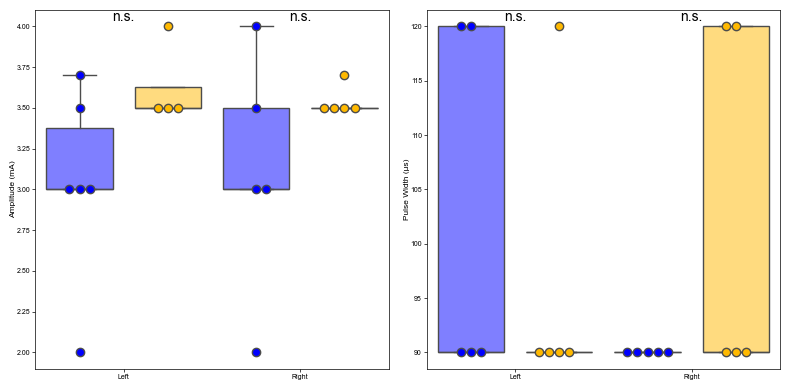

In [31]:
stim_setting_table = pd.DataFrame(columns=['pt_id', 'response_status', 'left_amp', 'right_amp', 'left_pw', 'right_pw'])
r_left_amps, r_right_amps, nr_left_amps, nr_right_amps = [], [], [], []
r_left_pws, r_right_pws, nr_left_pws, nr_right_pws = [], [], [], []
for pt_id in df.pt_id.unique():
    pt_df = df.query('pt_id == @pt_id and days_since_dbs == 14').copy()
    if pt_df.empty:
        continue
    response_status = pt_df['response_status'].iloc[0]
    left_amp = pt_df['stim_left'].max()
    right_amp = pt_df['stim_right'].max()
    try:
        left_pw = pt_df.dropna(subset='active_left_pulse_width').iloc[-1]['active_left_pulse_width']
    except IndexError:
        left_pw = np.nan
    try:
        right_pw = pt_df.dropna(subset='active_right_pulse_width').iloc[-1]['active_right_pulse_width']
    except IndexError:
        right_pw = np.nan
    
    stim_setting_table.loc[len(stim_setting_table)] = [pt_id, response_status, left_amp, right_amp, left_pw, right_pw]

    if response_status == 'Responder':
        if not np.isnan(left_amp):
            r_left_amps.append(left_amp)
        if not np.isnan(right_amp):
            r_right_amps.append(right_amp)
        if not np.isnan(left_pw):
            r_left_pws.append(left_pw)
        if not np.isnan(right_pw):
            r_right_pws.append(right_pw)
    elif response_status == 'Non-Responder':
        if not np.isnan(left_amp):
            nr_left_amps.append(left_amp)
        if not np.isnan(right_amp):
            nr_right_amps.append(right_amp)
        if not np.isnan(left_pw):
            nr_left_pws.append(left_pw)
        if not np.isnan(right_pw):
            nr_right_pws.append(right_pw)

left_amp_t_stat, left_amp_p_val = stats.ttest_ind(r_left_amps, nr_left_amps, equal_var=False)
left_amp_asterisk_str = get_asterisk_str(left_amp_p_val)
print(f'T-test comparing left hemisphere stimulation amplitudes between Responders and Non-Responders: t={left_amp_t_stat:.3f}, p={left_amp_p_val:.3e}')

right_amp_t_stat, right_amp_p_val = stats.ttest_ind(r_right_amps, nr_right_amps, equal_var=False)
right_amp_asterisk_str = get_asterisk_str(right_amp_p_val)
print(f'T-test comparing right hemisphere stimulation amplitudes between Responders and Non-Responders: t={right_amp_t_stat:.3f}, p={right_amp_p_val:.3e}')

left_pw_t_stat, left_pw_p_val = stats.ttest_ind(r_left_pws, nr_left_pws, equal_var=False)
left_pw_asterisk_str = get_asterisk_str(left_pw_p_val)
print(f'T-test comparing left hemisphere stimulation pulse widths between Responders and Non-Responders: t={left_pw_t_stat:.3f}, p={left_pw_p_val:.3e}')

right_pw_t_stat, right_pw_p_val = stats.ttest_ind(r_right_pws, nr_right_pws, equal_var=False)
right_pw_asterisk_str = get_asterisk_str(right_pw_p_val)
print(f'T-test comparing right hemisphere stimulation pulse widths between Responders and Non-Responders: t={right_pw_t_stat:.3f}, p={right_pw_p_val:.3e}')

fig, axs = plt.subplots(ncols=2, figsize=(8, 4))
plot_box_and_swarmplot(0, r_left_amps, axs[0], color=COL_PAL['Responder'], alpha=0.5)
plot_box_and_swarmplot(1, nr_left_amps, axs[0], color=COL_PAL['Non-Responder'], alpha=0.5)
plot_box_and_swarmplot(2, r_right_amps, axs[0], color=COL_PAL['Responder'], alpha=0.5)
plot_box_and_swarmplot(3, nr_right_amps, axs[0], color=COL_PAL['Non-Responder'], alpha=0.5)
plot_box_and_swarmplot(0, r_left_pws, axs[1], color=COL_PAL['Responder'], alpha=0.5)
plot_box_and_swarmplot(1, nr_left_pws, axs[1], color=COL_PAL['Non-Responder'], alpha=0.5)
plot_box_and_swarmplot(2, r_right_pws, axs[1], color=COL_PAL['Responder'], alpha=0.5)
plot_box_and_swarmplot(3, nr_right_pws, axs[1], color=COL_PAL['Non-Responder'], alpha=0.5)

axs[0].text(0.5, 1, left_amp_asterisk_str, ha='center', va='top', transform=axs[0].get_xaxis_transform())
axs[0].text(2.5, 1, right_amp_asterisk_str, ha='center', va='top', transform=axs[0].get_xaxis_transform())
axs[1].text(0.5, 1, left_pw_asterisk_str, ha='center', va='top', transform=axs[1].get_xaxis_transform())
axs[1].text(2.5, 1, right_pw_asterisk_str, ha='center', va='top', transform=axs[1].get_xaxis_transform())

axs[0].set(
    xticks=[0.5, 2.5],
    xticklabels=['Left', 'Right'],
    ylabel='Amplitude (mA)',
)
axs[1].set(
    xticks=[0.5, 2.5],
    xticklabels=['Left', 'Right'],
    ylabel='Pulse Width (µs)',
)

fig.tight_layout()
fig.savefig('figures/4g_h.svg', bbox_inches='tight', pad_inches=0)
stim_setting_table.to_excel('tables/stim_settings_at_14d.xlsx', index=False)
plt.show()

### 4i

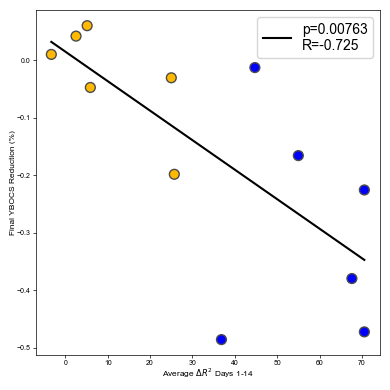

In [32]:
X, y, c = [], [], []

for pt_id, pt_df in df.groupby('pt_id'):
    response_status = pt_df['response_status'].iloc[0]
    if response_status == 'Unknown':
        continue
    first_14d_df = pt_df.query('days_since_dbs > 0 and days_since_dbs <= 14').groupby('days_since_dbs').head(1)
    first_14d_avg_feature = first_14d_df[feature].mean()
    if pd.isna(first_14d_avg_feature):
        continue

    response_status = pt_df['response_status'].iloc[0]
    final_symptom_reduction = scale_df.query('pt_id == @pt_id')['YBOCS_reduction'].iloc[-1] * 100

    if response_status == 'Unknown' or np.isnan(first_14d_avg_feature):
        continue
    if np.isnan(final_symptom_reduction):
        continue
    X.append(final_symptom_reduction)
    y.append(first_14d_avg_feature)
    c.append(COL_PAL[response_status])

yb_reductions = np.array(X)
delta_r2_14d = np.array(y)

fig, ax = plt.subplots(figsize=(4,4), sharex=True)
ax.scatter(yb_reductions, delta_r2_14d, c=c, s=50, edgecolor='#4c4c4c')

slope, intercept, r_value, p_value, std_err = stats.linregress(yb_reductions, delta_r2_14d)
line_xs = np.array([min(yb_reductions), max(yb_reductions)])
line_ys = intercept + slope * line_xs
ax.plot(line_xs, line_ys, color='k', label=f'p={p_value:.3g}\nR={r_value:.3g}')
ax.legend()

ax.set(
    xlabel=r'Average $\Delta R^2$ Days 1-14',
    ylabel='Final YBOCS Reduction (%)'
)

fig.tight_layout()
fig.savefig('figures/4i.svg', bbox_inches='tight', pad_inches=0)
plt.show()

## Figure 5

### 5a

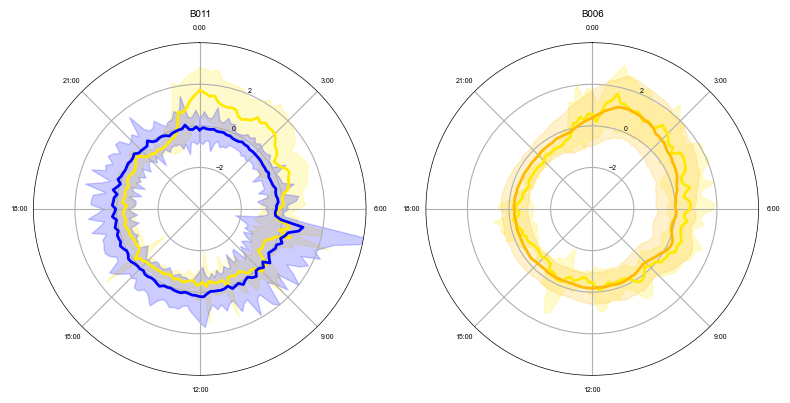

In [33]:
fig, axs = plt.subplots(ncols=2, figsize=(8, 4), subplot_kw={'projection': 'polar'})
for i, pt_id in enumerate(['B011', 'B006']):
    pt_df = df.query('pt_id == @pt_id').copy()
    predbs_pt_df = pt_df.query('days_since_dbs < 0')
    predbs_groups = predbs_pt_df.groupby('time_bin_time')
    predbs_means = predbs_groups['lfp_left_OvER_interpolate_z_scored'].mean().values
    predbs_stds = predbs_groups['lfp_left_OvER_interpolate_z_scored'].std().values

    response_state = pt_df['response_status'].iloc[0]
    stable_pt_df = pt_df.query('state_label_str == @response_state')
    postdbs_groups = stable_pt_df.groupby('time_bin_time')
    postdbs_means = postdbs_groups['lfp_left_OvER_interpolate_z_scored'].mean().values
    postdbs_stds = postdbs_groups['lfp_left_OvER_interpolate_z_scored'].std().values

    theta = np.linspace(0, 2 * np.pi, len(predbs_means)+1, endpoint=True)

    # Wrap around all the means and stds so that the polar plot is continuous
    predbs_means = np.concatenate([predbs_means, [predbs_means[0]]])
    predbs_stds = np.concatenate([predbs_stds, [predbs_stds[0]]])
    postdbs_means = np.concatenate([postdbs_means, [postdbs_means[0]]])
    postdbs_stds = np.concatenate([postdbs_stds, [postdbs_stds[0]]])

    axs[i].plot(theta, predbs_means, label=f'{pt_id} Pre-DBS', color=COL_PAL['Pre-DBS'], lw=2)
    axs[i].fill_between(theta, predbs_means - predbs_stds, predbs_means + predbs_stds, color=COL_PAL['Pre-DBS'], alpha=0.2)
    axs[i].plot(theta, postdbs_means, label=f'{pt_id} Post-DBS', color=COL_PAL[response_state], lw=2)
    axs[i].fill_between(theta, postdbs_means - postdbs_stds, postdbs_means + postdbs_stds, color=COL_PAL[response_state], alpha=0.2)
    
    axs[i].set(
        theta_zero_location='N',
        theta_direction=-1,
        xticks=np.linspace(0, 2 * np.pi, 8, endpoint=False),
        xticklabels=[f'{int(t)}:00' for t in np.linspace(0, 24, 8, endpoint=False)],
        yticks=[-2, 0, 2],
        ylim=[-4, 4]
    )

axs[0].set_title('B011')
axs[1].set_title('B006')

fig.tight_layout()
fig.savefig('figures/5a.svg', bbox_inches='tight', pad_inches=0)
plt.show()

### 5b

In [ ]:
WINDOW_DAYS   = 4
RESAMPLE_RULE = "30min"
N_BINS        = WINDOW_DAYS * 24 * 2
KEEP_STATES   = ("Pre-DBS", "Responder", "Non-Responder")
TARGET_H      = (6, 12, 24)
HEM_COL       = "lfp_left_OvER_interpolate_z_scored"

spectra = {pt: list(day_spectra(g.sort_values('dummy_timestamp')))
           for pt, g in df.groupby('pt_id', sort=False)}

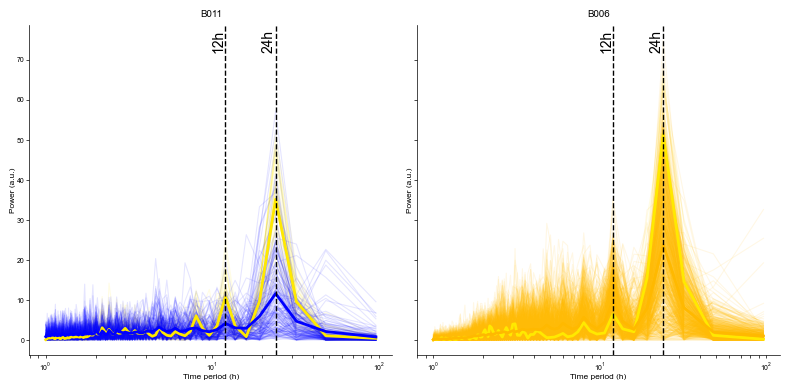

In [62]:
fig, axs = plt.subplots(ncols=2, figsize=(8, 4), sharey=True)
for ax, pt_id in zip(axs, ["B011", "B006"]):
    windows = spectra[pt_id]
    periods = windows[0][1]
    by_state = {}
    for state, _, pxx in windows:
        ax.plot(periods, pxx, color=COL_PAL[state], alpha=0.1, lw=0.8)
        by_state.setdefault(state, []).append(pxx)
    for state, stack in by_state.items():
        ax.plot(periods, np.nanmean(stack, axis=0), color=COL_PAL[state], lw=2, label=state)

    for period in (12, 24):
        ax.axvline(period, ls="--", color="k", lw=1)
        ax.text(period, 0.95, f"{period}h", ha="right", va="center", rotation=90, transform=ax.get_xaxis_transform())
    ax.set(
        xscale="log",
        xlabel="Time period (h)",
        ylabel="Power (a.u.)",
        title=pt_id
    )
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig('figures/5b.svg', bbox_inches='tight', pad_inches=0)
plt.show()

### 5c

Responder 6h: p=0.873
Responder 12h: p=0.007937
Responder 24h: p=0.02381
Non-Responder 6h: p=0.6623
Non-Responder 12h: p=0.2554
Non-Responder 24h: p=0.2273


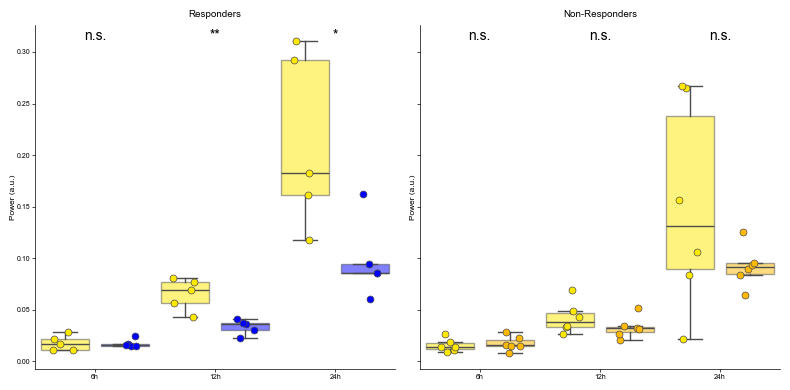

In [63]:
records = []
for pt_id, windows in spectra.items():
    resp = df.loc[df.pt_id == pt_id, "response_status"].iloc[0]
    if resp not in ("Responder", "Non-Responder"):
        continue
    phases_present = {"Pre-DBS" if state == "Pre-DBS" else "Post-DBS" for state, _, _ in windows}
    if not {"Pre-DBS", "Post-DBS"} <= phases_present:
        continue
    phase_powers = {"Pre-DBS": {p: [] for p in TARGET_H},
                    "Post-DBS": {p: [] for p in TARGET_H}}

    for state, periods, pxx in windows:
        phase = "Pre-DBS" if state == "Pre-DBS" else "Post-DBS"
        for p, v in normed_powers(periods, pxx).items():
            phase_powers[phase][p].append(v)
    for phase in ("Pre-DBS", "Post-DBS"):
        for p in TARGET_H:
            vals = phase_powers[phase][p]
            records.append({"pt_id": pt_id, "response": resp, "phase": phase,
                            "period_h": p, "power": np.nanmean(vals) if vals else np.nan})
power_df = pd.DataFrame(records)

rng = np.random.default_rng(0)
ec = '#4c4c4c'
def box_with_points(ax, x, vals, color, width=0.8):
    if not vals:
        return
    ax.boxplot(vals, positions=[x], widths=width, showfliers=False, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.5, edgecolor=ec),
               medianprops=dict(color=ec), whiskerprops=dict(color=ec),
               capprops=dict(color=ec))
    jitter = (rng.random(len(vals)) - 0.5) * width * 0.5
    ax.scatter(x + jitter, vals, color=color, edgecolor=ec, lw=0.5, s=25, zorder=3)

def statistic(x, y, axis):
    return np.mean(x, axis=axis) - np.mean(y, axis=axis)

fig, axs = plt.subplots(ncols=2, figsize=(8, 4), sharey=True)
for ax, resp in zip(axs, ["Responder", "Non-Responder"]):
    sub = power_df[power_df.response == resp]
    for i, p in enumerate(TARGET_H):
        pre = sub.query("phase == 'Pre-DBS'  and period_h == @p")["power"].dropna().tolist()
        post = sub.query("phase == 'Post-DBS' and period_h == @p")["power"].dropna().tolist()
        box_with_points(ax, i * 2, pre, COL_PAL["Pre-DBS"])
        box_with_points(ax, i * 2 + 1, post, COL_PAL[resp])

        paired = (sub.query("period_h == @p")
                     .pivot(index="pt_id", columns="phase", values="power").dropna())
        if len(paired) > 1:
            perm_res = stats.permutation_test((paired["Pre-DBS"], paired["Post-DBS"]), statistic=statistic, vectorized=True)
            pval = perm_res.pvalue
            print(f'{resp} {p}h: p={pval:.4g}')
            ax.text(i * 2 + 0.5, 0.95, get_asterisk_str(pval),
                    ha="center", va="bottom", transform=ax.get_xaxis_transform())

    ax.set(xticks=[i * 2 + 0.5 for i in range(len(TARGET_H))],
           xticklabels=[f"{p}h" for p in TARGET_H],
           ylabel="Power (a.u.)", title=f"{resp}s")
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
power_df.to_excel('tables/5c_power_stats.xlsx', index=False)
fig.savefig('figures/5c.svg', bbox_inches='tight', pad_inches=0)
plt.show()

### 5d

In [37]:
circadian_dict = {'pt_id': [], 'state': [], 'response_status': [],
                  'left_mean_acrophase_rad': [], 'left_mean_acrophase_hr': [],
                  'left_mean_amplitude': [], 'left_mean_mesor': [],
                  'right_mean_acrophase_rad': [], 'right_mean_acrophase_hr': [],
                  'right_mean_amplitude': [], 'right_mean_mesor': []
                 }

for pt_id, pt_df in df.groupby(['pt_id', 'days_since_dbs'], sort=False).head(1).groupby('pt_id', sort=False):
    response_status = pt_df['response_status'].iloc[0]
    for i, (state_name, query_str) in enumerate([
        ('Pre-DBS', 'state_label_str == "Pre-DBS"'),
        ('First 14d', 'days_since_dbs > 0 and days_since_dbs <= 14'),
        ('Stable', 'state_label_str == @response_status')
    ]):
        query_df = pt_df.query(query_str)
        if query_df.empty:
            continue
        left_acro_rad, left_acro_hr, left_amp, left_mesor = query_df[['left_cosinor_acrophase_rad', 'left_cosinor_acrophase_hr', 'left_cosinor_amplitude', 'left_cosinor_mesor']].T.values

        left_mean_acrophase_rad = stats.circmean(left_acro_rad, low=0, high=2*np.pi, nan_policy='omit') if not np.all(np.isnan(left_acro_rad)) else np.nan
        left_mean_acrophase_hr = stats.circmean(left_acro_hr, low=0, high=24, nan_policy='omit') if not np.all(np.isnan(left_acro_hr)) else np.nan
        left_mean_amplitude = np.nanmean(left_amp) if not np.all(np.isnan(left_amp)) else np.nan
        left_mean_mesor = np.nanmean(left_mesor) if not np.all(np.isnan(left_mesor)) else np.nan

        right_acro_rad, right_acro_hr, right_amp, right_mesor = query_df[['right_cosinor_acrophase_rad', 'right_cosinor_acrophase_hr', 'right_cosinor_amplitude', 'right_cosinor_mesor']].T.values

        right_mean_acrophase_rad = stats.circmean(right_acro_rad, low=0, high=2*np.pi, nan_policy='omit') if not np.all(np.isnan(right_acro_rad)) else np.nan
        right_mean_acrophase_hr = stats.circmean(right_acro_hr, low=0, high=24, nan_policy='omit') if not np.all(np.isnan(right_acro_hr)) else np.nan
        right_mean_amplitude = np.nanmean(right_amp) if not np.all(np.isnan(right_amp)) else np.nan
        right_mean_mesor = np.nanmean(right_mesor) if not np.all(np.isnan(right_mesor)) else np.nan

        circadian_dict['pt_id'].append(pt_id)
        circadian_dict['state'].append(state_name)
        circadian_dict['response_status'].append(response_status)
        circadian_dict['left_mean_acrophase_rad'].append(left_mean_acrophase_rad)
        circadian_dict['left_mean_acrophase_hr'].append(left_mean_acrophase_hr)
        circadian_dict['left_mean_amplitude'].append(left_mean_amplitude)
        circadian_dict['left_mean_mesor'].append(left_mean_mesor)
        circadian_dict['right_mean_acrophase_rad'].append(right_mean_acrophase_rad)
        circadian_dict['right_mean_acrophase_hr'].append(right_mean_acrophase_hr)
        circadian_dict['right_mean_amplitude'].append(right_mean_amplitude)
        circadian_dict['right_mean_mesor'].append(right_mean_mesor)

circadian_df = pd.DataFrame(circadian_dict)

MWW test comparing acrophase between responders and non-responders in Pre-DBS: W=15.2, p=0.000501


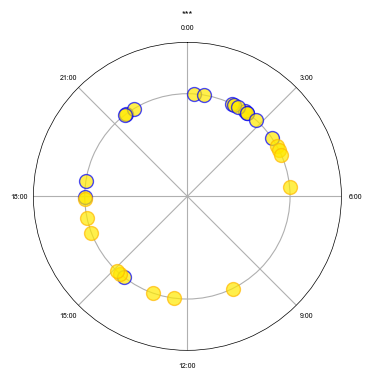

In [38]:
state = 'Pre-DBS'
fig, ax = plt.subplots(figsize=(4,4), subplot_kw={'projection': 'polar'})

responder_acros_rad = circadian_df.query(f'state == "{state}" and response_status == "Responder"')[['left_mean_acrophase_rad', 'right_mean_acrophase_rad']].values.flatten()
nonresponder_acros_rad = circadian_df.query(f'state == "{state}" and response_status == "Non-Responder"')[['left_mean_acrophase_rad', 'right_mean_acrophase_rad']].values.flatten()
# remove nans from each array
responder_acros_rad = responder_acros_rad[~np.isnan(responder_acros_rad)]
nonresponder_acros_rad = nonresponder_acros_rad[~np.isnan(nonresponder_acros_rad)]

ax.scatter(responder_acros_rad, np.ones_like(responder_acros_rad), color=COL_PAL['Pre-DBS'], ec=COL_PAL['Responder'], alpha=0.7, s=100, zorder=5)
ax.scatter(nonresponder_acros_rad, np.ones_like(nonresponder_acros_rad), color=COL_PAL['Pre-DBS'], ec=COL_PAL['Non-Responder'], alpha=0.7, s=100, zorder=5)

ax.set(
    theta_zero_location='N',
    theta_direction=-1,
    xticks=np.linspace(0, 2 * np.pi, 8, endpoint=False),
    xticklabels=[f'{int(t)}:00' for t in np.linspace(0, 24, 8, endpoint=False)],
    yticks=[1],
    yticklabels=[''],
    ylim=[0, 1.5]
)

W, p_perm, dof, p_chi = mww_permutation_pvalue(responder_acros_rad, nonresponder_acros_rad,
                                               units='radians', B=10000, random_state=42)
p_val = p_chi if (len(responder_acros_rad) + len(nonresponder_acros_rad) > 14) else p_perm
print(f'MWW test comparing acrophase between responders and non-responders in {state}: W={W:.3g}, p={p_val:.3g}')
ax.set_title(get_asterisk_str(p_val))

fig.savefig('figures/5d.svg', bbox_inches='tight', pad_inches=0)
circadian_df.query(f'state == "{state}"')[['pt_id', 'response_status', 'left_mean_acrophase_rad', 'right_mean_acrophase_rad']].to_excel('tables/5g_acrophase_stats.xlsx', index=False)
plt.show()

### 5e

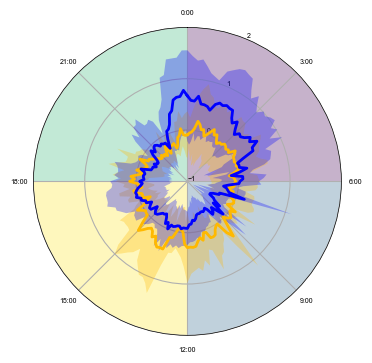

In [39]:
fig, ax = plt.subplots(figsize=(4,4), subplot_kw={'projection': 'polar'})
predbs_df = df.query('days_since_dbs < 0').copy()

for status, status_predbs_df in predbs_df.groupby('response_status'):
    if status == 'Unknown':
        continue

    pt_bin_means = (
        status_predbs_df
        .groupby(['pt_id', 'time_bin_time'])['lfp_left_OvER_interpolate_z_scored']
        .mean()
    )
    means_series = pt_bin_means.groupby('time_bin_time').mean()
    stds_series = pt_bin_means.groupby('time_bin_time').std()  # spread across patients, per bin

    time_bins = means_series.index.tolist()  # sorted datetime.time values, 10-min bins
    means = means_series.values
    stds = stds_series.values

    theta = np.array([(t.hour + t.minute / 60 + t.second / 3600) / 24 * 2 * np.pi for t in time_bins])
    theta = np.concatenate([theta, [theta[0] + 2 * np.pi]])
    means = np.concatenate([means, [means[0]]])
    stds = np.concatenate([stds, [stds[0]]])

    ax.plot(theta, means, label=status, color=COL_PAL[status], lw=2, zorder=8)
    ax.fill_between(theta, means - stds, means + stds, color=COL_PAL[status], alpha=0.3, edgecolor='none', zorder=5)

rmin, rmax = -1, 2
viridis = mpl.colormaps['viridis']
sample_points = np.linspace(0, 1, 4)
colors_in_colormap_order = [mcolors.to_hex(viridis(p)) for p in sample_points]
q1, q2, q3, q4 = colors_in_colormap_order[0], colors_in_colormap_order[1], colors_in_colormap_order[3], colors_in_colormap_order[2]
quadrants = [
    (0, np.pi/2, q1),
    (np.pi/2, np.pi, q2),
    (np.pi, 3*np.pi/2, q3),
    (3*np.pi/2, 2*np.pi, q4),
]
theta_fine = np.linspace(0, 2*np.pi, 1001, endpoint=True)
for start, end, color in quadrants:
    mask = (theta_fine >= start) & (theta_fine <= end)
    ax.fill_between(theta_fine[mask], rmin, rmax,
                    color=color, alpha=0.3, zorder=0, ec=None)

ax.set(
    theta_zero_location='N',
    theta_direction=-1,
    xticks=np.linspace(0, 2 * np.pi, 8, endpoint=False),
    xticklabels=[f'{int(t)}:00' for t in np.linspace(0, 24, 8, endpoint=False)],
    yticks=[-1, 0, 1, 2],
    ylim=[rmin, rmax]
)

fig.savefig('figures/5e.svg', bbox_inches='tight', pad_inches=0)
plt.show()

### 5f

MLM results:
                             Mixed Linear Model Regression Results
Model:                           MixedLM              Dependent Variable:              power   
No. Observations:                56                   Method:                          ML      
No. Groups:                      14                   Scale:                           0.0967  
Min. group size:                 4                    Log-Likelihood:                  -14.0405
Max. group size:                 4                    Converged:                       Yes     
Mean group size:                 4.0                                                           
-----------------------------------------------------------------------------------------------
                                                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------------
Intercept                                             0.

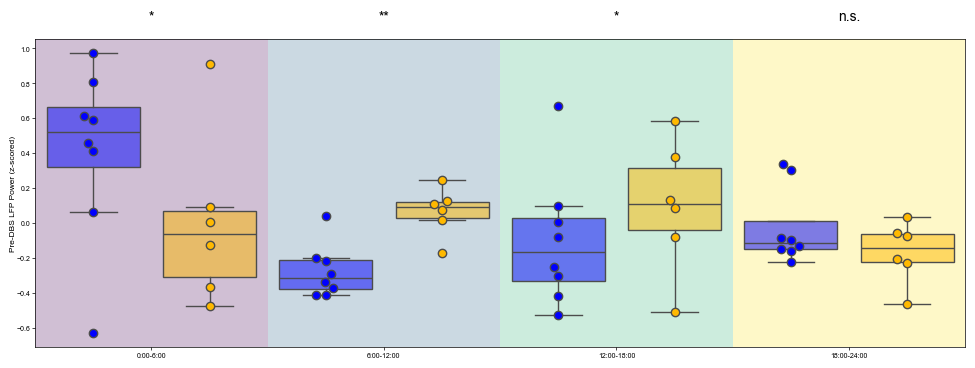

In [40]:
feat = 'lfp_left_OvER_interpolate_z_scored'
quadrants = [(0, 6), (6, 12), (12, 18), (18, 0)]
quadrant_labels = ['0:00-6:00', '6:00-12:00', '12:00-18:00', '18:00-24:00']

predbs_df = df.query('days_since_dbs < 0')

pt_feature_dict = {}
for quadrant in quadrants:
    start_hr, end_hr = quadrant
    start_hr, end_hr = dttime(start_hr, 0), dttime(end_hr, 0)

    for pt_id, predbs_pt_df in predbs_df.groupby('pt_id'):
        response_status = predbs_pt_df['response_status'].iloc[0]
        if response_status == 'Unknown':
            continue
        if predbs_pt_df.empty:
            continue

        if start_hr < end_hr:
            quadrant_df = predbs_pt_df.query('time_bin_time >= @start_hr and time_bin_time < @end_hr')
        else:
            quadrant_df = predbs_pt_df.query('time_bin_time >= @start_hr or time_bin_time < @end_hr')
        if quadrant_df.empty:
            continue
        quadrant_mean = quadrant_df[feat].mean()
        if pd.isna(quadrant_mean):
            continue

        pt_feature_dict.setdefault(pt_id, {'response_status': response_status})
        pt_feature_dict[pt_id][quadrant] = quadrant_mean
        
pt_feature_df = pd.DataFrame.from_dict(pt_feature_dict, orient='index')
pt_feature_df = pt_feature_df.rename(columns=dict(zip(quadrants, quadrant_labels)))
pt_feature_df.dropna(subset=quadrant_labels, inplace=True, how='any')

quadrant_power_dict = {
    quadrant: {
        status: pt_feature_df.loc[pt_feature_df['response_status'] == status, label].dropna().tolist()
        for status in ['Responder', 'Non-Responder']
    }
    for quadrant, label in zip(quadrants, quadrant_labels)
}

fig, ax = plt.subplots(figsize=(12, 4))

plot_box_and_swarmplot(0, quadrant_power_dict[(0, 6)]['Responder'], ax, color=COL_PAL['Responder'], alpha=0.5, widths=0.8)
plot_box_and_swarmplot(1, quadrant_power_dict[(0, 6)]['Non-Responder'], ax, color=COL_PAL['Non-Responder'], alpha=0.5, widths=0.8)

plot_box_and_swarmplot(2, quadrant_power_dict[(6, 12)]['Responder'], ax, color=COL_PAL['Responder'], alpha=0.5, widths=0.8)
plot_box_and_swarmplot(3, quadrant_power_dict[(6, 12)]['Non-Responder'], ax, color=COL_PAL['Non-Responder'], alpha=0.5, widths=0.8)

plot_box_and_swarmplot(4, quadrant_power_dict[(12, 18)]['Responder'], ax, color=COL_PAL['Responder'], alpha=0.5, widths=0.8)
plot_box_and_swarmplot(5, quadrant_power_dict[(12, 18)]['Non-Responder'], ax, color=COL_PAL['Non-Responder'], alpha=0.5, widths=0.8)

plot_box_and_swarmplot(6, quadrant_power_dict[(18, 0)]['Responder'], ax, color=COL_PAL['Responder'], alpha=0.5, widths=0.8)
plot_box_and_swarmplot(7, quadrant_power_dict[(18, 0)]['Non-Responder'], ax, color=COL_PAL['Non-Responder'], alpha=0.5, widths=0.8)

# Mixed LM to compare responder avg power values and non-responder avg power values across time bins

# Reformat feature dataframe
pt_feature_df['pt_id'] = pt_feature_df.index
mlm_df = pt_feature_df.melt(id_vars=['pt_id', 'response_status'], var_name='time_bin', value_name='power')
mlm_df.dropna(subset='power', inplace=True)

# Mixed LM 
summary_df, interaction_terms = run_mixedlm(mlm_df, verbose=True)
sig_vals = interaction_terms.sort_values(by='time_bins')['pvalue'].values

for i, quadrant in enumerate(quadrants):
    if quadrant == (18, 0): quadrant = (18, 24)
    pval = interaction_terms.loc[interaction_terms['time_bins'] == quadrant, 'pvalue'].values
    if len(pval) > 0:
        asterisk_str = get_asterisk_str(pval[0])
        print(f'Quadrant {quadrant}: p = {pval[0]:.3g}, asterisk_str = {asterisk_str}')
    else:
        asterisk_str = 'n/a'
    x_pos = i * 2 + 0.5
    ax.text(x_pos, ax.get_ylim()[1], asterisk_str, ha='center', va='bottom', transform=ax.get_xaxis_transform())

ylim = ax.get_ylim()
sample_points = np.linspace(0, 1, 4)
colors_in_colormap_order = [mcolors.to_hex(viridis(p)) for p in sample_points]
for i, (start, end) in enumerate(quadrants):
    color = colors_in_colormap_order[i]
    ax.fill_betweenx(ylim, i*2-.5, i*2+1.5, color=color, alpha=0.25, ec=None, zorder=0)

ax.set(
    xticks=[0.5, 2.5, 4.5, 6.5],
    xticklabels=quadrant_labels,
    ylabel='Pre-DBS LFP Power (z-scored)',
    ylim=ylim
)

pt_feature_df.to_excel('tables/5f_quadrant_power_stats.xlsx', index=False)
fig.savefig('figures/5f.svg', bbox_inches='tight', pad_inches=0)
plt.show()

### 5g

B001: ['0:00-6:00', '12:00-18:00', '18:00-24:00', '6:00-12:00']
B002: []
B004: ['6:00-12:00']
B005: ['0:00-6:00', '12:00-18:00', '6:00-12:00']
B006: ['0:00-6:00', '12:00-18:00', '18:00-24:00', '6:00-12:00']
B007: ['0:00-6:00', '12:00-18:00', '6:00-12:00']
B008: ['0:00-6:00', '12:00-18:00', '6:00-12:00']
B010: ['12:00-18:00', '6:00-12:00']
B011: ['6:00-12:00']
B013: ['0:00-6:00', '12:00-18:00', '6:00-12:00']
B019: ['0:00-6:00', '12:00-18:00', '6:00-12:00']
U001: ['6:00-12:00']
U003: ['0:00-6:00', '12:00-18:00', '6:00-12:00']
U004: ['0:00-6:00', '12:00-18:00', '6:00-12:00']


  0%|          | 0/10000 [00:00<?, ?it/s]

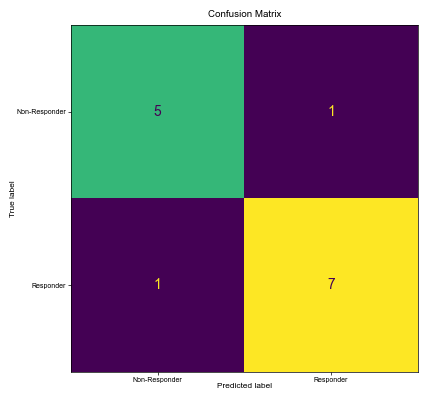

AUC: 0.833, p = 0.0153


In [ ]:
y_true, y_prob = [], []
model_df = pt_feature_df.copy()
model_df['response_status'] = pt_feature_df['response_status'].map({'Responder': 1, 'Non-Responder': 0})
model_df.dropna(subset=quadrant_labels, inplace=True, how='any')
# Manual LOPO for unique pt-fold feature selection
for pt_id in model_df.pt_id.unique():
    feature_train_df = mlm_df.query('pt_id != @pt_id')

    summary_df, interaction_terms = run_mixedlm(feature_train_df, correction=True)
    sig_bins = interaction_terms.loc[interaction_terms['pvalue'] <= 0.05, 'time_bins'].values
    sig_bins = [(f'{bin[0]}:00-{bin[1]}:00') for bin in sig_bins]

    print(f'{pt_id}: {sig_bins}')
    if len(sig_bins) == 0:
        sig_bins = quadrant_labels # If no bins are significant, use all bins for prediction
        
    train_df = model_df.query('pt_id != @pt_id')
    test_df = model_df.query('pt_id == @pt_id')

    X_train = train_df[sig_bins].values
    y_train = train_df['response_status'].values

    X_test = test_df[sig_bins].values
    y_test = test_df['response_status'].values

    model = LDA()
    model.fit(X_train, y_train)
    y_prob.append(model.predict_proba(X_test)[:, 1][0])
    y_true.extend(y_test)

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

roc_dist = []
for _ in tqdm(range(10000)):
    y_shuffled = np.random.permutation(y_true)
    tmp_roc_auc = roc_auc_score(y_shuffled, y_prob)
    roc_dist.append(tmp_roc_auc)

fig, ax = plt.subplots(figsize=(4.5, 4.5))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Responder', 'Responder'])
disp.plot(ax=ax, cmap='viridis', colorbar=False)
ax.set_title('Confusion Matrix')

fig.savefig('figures/5g.svg', bbox_inches='tight', pad_inches=0)
plt.show()

print(f'AUC: {roc_auc:.3f}, p = {np.sum(np.array(roc_dist) > roc_auc) / (len(roc_dist) + 1):.3g}')

In [49]:
df.to_parquet('data/df_for_paper_processed.parq')